In [1]:
import pandas as pd
from sklearn.metrics import classification_report
import seaborn as sns



from process_and_save_recording import load_recording, convert_events_to_watch_time
from plot_signal import plot_signal

In [2]:
def lv_float(value, digits=2):
    return f"{value:.{digits}f}".replace(".", ",")

In [3]:
path = "session_1777462103399"
accel, gyro, classification, annotation, info = load_recording(path)

In [4]:
events_watch_time = convert_events_to_watch_time(annotation, info)

In [5]:
events_watch_time

[{'name': 'Crunches',
  'start_watch': 1777462349384,
  'end_watch': 1777462393955},
 {'name': 'Goblet Squats',
  'start_watch': 1777462620883,
  'end_watch': 1777462645157},
 {'name': 'Goblet Squats',
  'start_watch': 1777463015180,
  'end_watch': 1777463039059},
 {'name': 'Single Leg Romanian Deadlifts',
  'start_watch': 1777463468261,
  'end_watch': 1777463528203},
 {'name': 'Single Leg Romanian Deadlifts',
  'start_watch': 1777463830558,
  'end_watch': 1777463887162},
 {'name': 'Incline Dumbbell Bench Press',
  'start_watch': 1777464180380,
  'end_watch': 1777464207393},
 {'name': 'Incline Dumbbell Bench Press',
  'start_watch': 1777464459281,
  'end_watch': 1777464483773},
 {'name': 'Incline Dumbbell Curls',
  'start_watch': 1777464741084,
  'end_watch': 1777464796011},
 {'name': 'Incline Dumbbell Curls',
  'start_watch': 1777465018561,
  'end_watch': 1777465060599},
 {'name': 'Dips', 'start_watch': 1777465398863, 'end_watch': 1777465416018},
 {'name': 'Dips', 'start_watch': 17774

In [6]:
classification

,timestamp,prediction_float,prediction_binary,accel_timestamps,gyro_timestamps,window_data
0,1777462104036,0.014872,0,177015324722883;177015342756614;17701536279134...,177015324725345;177015342759306;17701536279380...,0.05267244|-0.3184288|9.730036|0.29443705|0.06...
1,1777462105052,0.029558,0,177016325628379;177016345636302;17701636572268...,177016325630687;177016345638879;17701636572503...,0.29927522|-0.5315128|9.78989|-0.02321288|-0.0...
2,1777462106060,0.037717,0,177017327272222;177017347310414;17701736735202...,177017327274529;177017347312952;17701736735437...,0.18914193|-0.093373865|9.816227|-0.040317107|...
3,1777462107050,0.077905,0,177018329547910;177018349617218;17701837170094...,177018329550218;177018349619795;17701837170325...,0.15083471|-0.21787235|9.706094|-0.040317107|0...
4,1777462108072,0.003745,0,177019333760522;177019351794829;17701937183232...,177019333764791;177019351797406;17701937183463...,-0.47405192|-0.50278234|9.797073|-0.04886922|-...
...,...,...,...,...,...,...
7184,1777469763270,0.350637,0,184654974690783;184654994774052;18465501486128...,184654974693244;184654994776244;18465501486370...,2.7030537|-8.990228|-3.217807|-0.41538838|0.01...
7185,1777469764491,0.302763,0,184674774326438;184674794412015;18467481449793...,184674774328630;184674794414438;18467481450016...,5.33907|-11.145009|3.3566709|-0.33108896|-0.45...
7186,1777469787305,0.022782,0,184676763719046;184676781513892;18467680161043...,184676763721469;184676781516084;18467680161289...,4.0198646|-7.788338|-0.107739076|0.16371189|0....
7187,1777469788308,0.010067,0,184677766438004;184677786552427;18467780667288...,184677766440427;184677786554619;18467780667531...,8.671799|-2.2098482|-1.5466543|0.9334021|0.076...


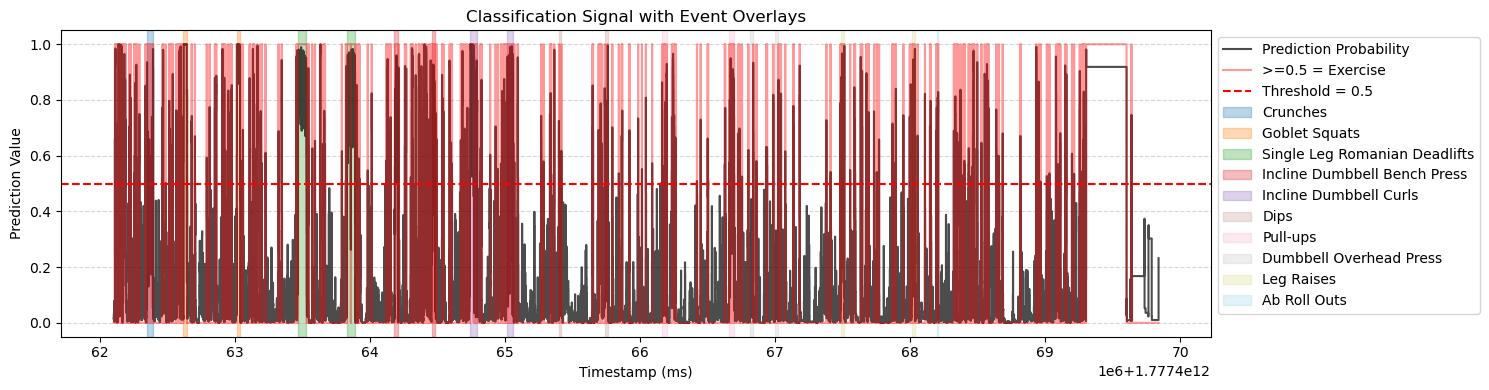

In [7]:
plot_signal(classification, events_watch_time)

In [8]:
# ignore treadmill running
# ignore_list = ['Treadmill Running', 'Side Crunches',
               #'Chest Fly Machine', 'Dumbbell Overhead Press', 'Cable Rows'
               #]
# filtered_events = [e for e in events_watch_time if e['name'] not in ignore_list]

In [9]:
def add_ground_truth(df, events):
    df['ground_truth'] = 0
    for event in events:
        mask = (df['timestamp'] >= event['start_watch']) & (df['timestamp'] <= event['end_watch'])
        df.loc[mask, 'ground_truth'] = 1
    
    return df

In [10]:
classification = add_ground_truth(classification, events_watch_time)

In [11]:
ignore_list_non_dataset_exercises = ["Ab Crunch Machine","Leg Raises",
"Side Crunches",
"Ab Roll Outs",
"Preacher Curls",
"Back Extensions",
"Pull-ups",
"Chest Fly Machine",
"Chest Press Machine",
"Cable Chest Fly",
"Bulgarian Split Squat",
"Romanian Deadlifts",
"Stiff-Leg Deadlifts",
"Machine Deadlifts",
"Single Leg Romanian Deadlifts",]

ignore_list = []

def remove_ignored_exercises(clf, events, ignore_list):
    df = clf.copy()
    filtered_events =  [e for e in events if e["name"] not in ignore_list]
    ignored_events  = [e for e in events if e["name"] in ignore_list]

    ignore_buffer_ms = 20000
    for ie in ignored_events:
        start = ie["start_watch"] - ignore_buffer_ms
        end = ie["end_watch"] + ignore_buffer_ms
        df = clf[(clf["timestamp"] < start) | (clf["timestamp"] > end)]

    return df, filtered_events

In [12]:
classification, events = remove_ignored_exercises(classification, events_watch_time, ignore_list)

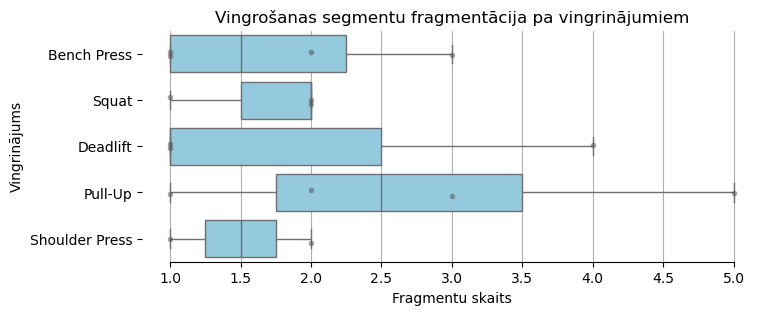

In [13]:
from matplotlib import pyplot as plt


def plot_fragmentation_per_exercise(fragmentation_df):
    f, ax = plt.subplots(figsize=(8, max(3, fragmentation_df["name"].nunique() * 0.3)))

    sns.boxplot(
        data=fragmentation_df,
        x="fragment_count",
        y="name",
        color="skyblue",
        whis=[0, 100]
    )

    sns.stripplot(
        data=fragmentation_df,
        x="fragment_count",
        y="name",
        size=4,
        color=".3",
        alpha=0.5
    )

    ax.set(
        xlabel="Fragmentu skaits",
        ylabel="Vingrinājums",
        title="Vingrošanas segmentu fragmentācija pa vingrinājumiem"
    )

    ax.xaxis.grid(True)
    sns.despine(trim=True, left=True)

fragmentation_df = pd.DataFrame({
    "name": [
        "Bench Press", "Bench Press", "Bench Press", "Bench Press",
        "Squat", "Squat", "Squat",
        "Deadlift", "Deadlift", "Deadlift",
        "Pull-Up", "Pull-Up", "Pull-Up", "Pull-Up",
        "Shoulder Press", "Shoulder Press"
    ],
    "fragment_count": [
        1, 1, 2, 3,
        1, 2, 2,
        1, 1, 4,
        1, 2, 3, 5,
        1, 2
    ]
})

plot_fragmentation_per_exercise(fragmentation_df)

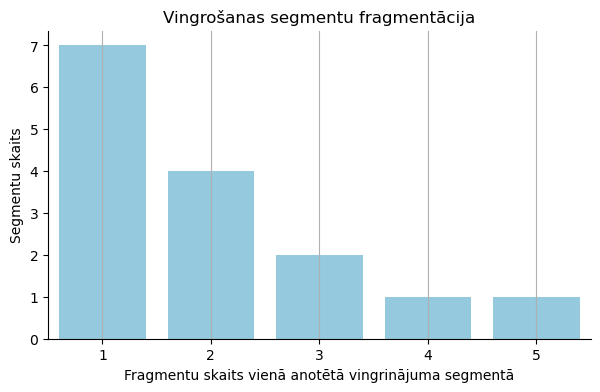

In [14]:
# Fake example data
fragmentation_df = pd.DataFrame({
    "fragment_count": [
        1, 1, 1, 1, 1, 1, 1,
        2, 2, 2, 2,
        3, 3,
        4,
        5
    ]
})

def plot_fragmentation_distribution(fragmentation_df):
    f, ax = plt.subplots(figsize=(7, 4))

    sns.countplot(
        data=fragmentation_df,
        x="fragment_count",
        color="skyblue"
    )

    ax.set(
        xlabel="Fragmentu skaits vienā anotētā vingrinājuma segmentā",
        ylabel="Segmentu skaits",
        title="Vingrošanas segmentu fragmentācija"
    )

    ax.xaxis.grid(True)

    sns.despine()

    plt.show()

plot_fragmentation_distribution(fragmentation_df)

# Metrics

In [15]:
from matplotlib import pyplot as plt
import numpy as np
from sklearn.metrics import PrecisionRecallDisplay, precision_recall_curve


def plot_pr_curve(data_y, preds):
    precision, recall, thresholds = precision_recall_curve(data_y, preds)
    pr_display = PrecisionRecallDisplay(precision=precision, recall=recall).plot()

    fig, ax = plt.subplots()

    # Plot colored line segments by threshold value
    print(precision)
    sc = ax.scatter(recall[:-1], precision[:-1], c=thresholds, cmap="viridis", s=10)
    plt.colorbar(sc, ax=ax, label="Threshold")
    
    ax.set_xlabel("Recall")
    ax.set_ylabel("Precision")
    ax.set_title("Precision-Recall Curve")

    fig, ax = plt.subplots()
    PrecisionRecallDisplay(precision=precision, recall=recall).plot(ax=ax)
    
    # Pick which thresholds to annotate
    thresholds_to_mark = [0.2, 0.5, 0.8]
    
    for thresh in thresholds_to_mark:
        idx = np.argmin(np.abs(thresholds - thresh))  # closest index
        ax.annotate(
            f"{thresh}",
            xy=(recall[idx], precision[idx]),
            xytext=(10, -10),
            textcoords="offset points",
            arrowprops=dict(arrowstyle="->", color="red"),
            fontsize=8,
            color="red",
        )
        ax.plot(recall[idx], precision[idx], "ro", markersize=5)
    
    ax.set_title("Precision-Recall Curve with Thresholds")
    plt.show()

[0.07761858 0.4137931  1.        ]


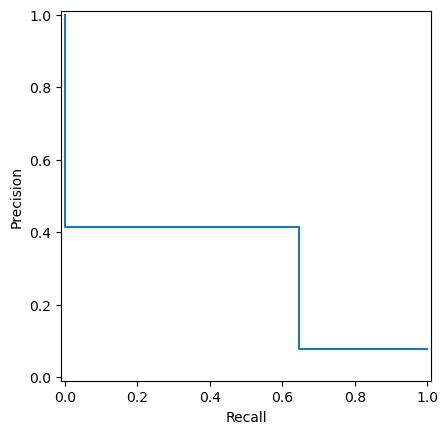

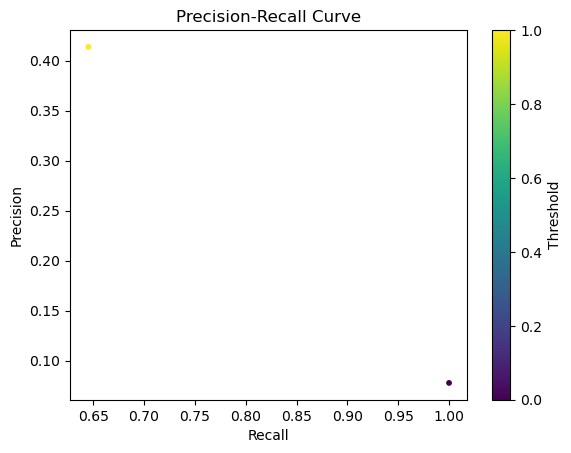

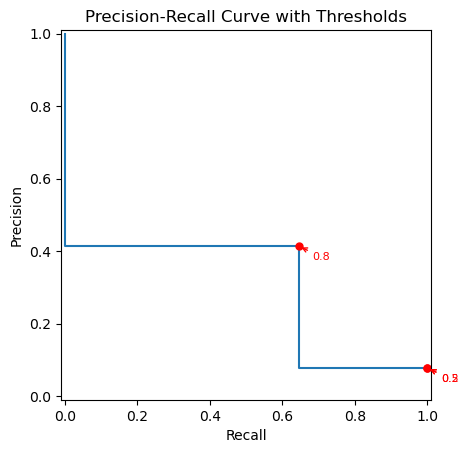

In [16]:
plot_pr_curve(classification["ground_truth"], classification["prediction_binary"])

In [17]:
print(classification_report(classification["ground_truth"], classification["prediction_binary"]))

              precision    recall  f1-score   support

           0       0.97      0.92      0.95      6631
           1       0.41      0.65      0.50       558

    accuracy                           0.90      7189
   macro avg       0.69      0.78      0.72      7189
weighted avg       0.93      0.90      0.91      7189



# Detection delay

In [18]:
def calculate_detection_timing(classification, events, buffer_ms=0):
    results = []
    
    for event in events:
        name = event['name']
        start = event['start_watch']
        end = event['end_watch']
        
        # Filter classification rows that occur during this specific event
        # We add a small buffer (e.g., 5 seconds) just in case the detection is late
        mask = (classification['timestamp'] >= start - buffer_ms) & (classification['timestamp'] <= end)
        event_predictions = classification.loc[mask]
        
        if event_predictions.empty:
            results.append({'name': name, 'delay_ms': None, 'status': 'Not Detected'})
            continue
            
        # Find the when the model predicted '1' (Exercise)
        detected_rows = event_predictions[event_predictions['prediction_binary'] == 1]

        if not detected_rows.empty:
            # order by closest to start
            detected_rows['dist_to_start'] = (detected_rows['timestamp'] - start).abs()

            # Sort by distance and take the closest one
            closest_row = detected_rows.sort_values('dist_to_start').iloc[0]

            first_detection_ts = closest_row['timestamp']
            delay = first_detection_ts - start
            
            results.append({
                'name': name, 
                'delay_ms': round(delay, 2), 
                'delay_sec': round(delay / 1000, 2),
                'status': 'Detected'
            })
        else:
            results.append({'name': name, 'delay_ms': None, 'status': 'Missed'})

    return pd.DataFrame(results)

def calculate_latency_metrics(classification, events):
    latency_df = calculate_detection_timing(
        classification,
        events,
        buffer_ms=0
    )

    detected_latencies = latency_df.loc[
        latency_df["status"] == "Detected",
        "delay_sec"
    ].dropna().astype(float)

    return {
        "mean_latency": detected_latencies.mean(),
        "median_latency": detected_latencies.median(),
        "std_latency": detected_latencies.std(),
        "min_latency": detected_latencies.min(),
        "max_latency": detected_latencies.max(),
        "Q1_latency": detected_latencies.quantile(0.25),
        "Q3_latency": detected_latencies.quantile(0.75),
        "P95": detected_latencies.quantile(0.95),
        "detected_events": len(detected_latencies),
        "total_events": len(events),
        "detection_rate": len(detected_latencies) / len(events) if events else 0
    }, latency_df

latency_metrics, latency_df = calculate_latency_metrics(classification, events)
print(latency_df)
for key, value in latency_metrics.items():
    print(f"{key}: {value:.2f}")

                             name  delay_ms  delay_sec    status
0                        Crunches     288.0       0.29  Detected
1                   Goblet Squats     657.0       0.66  Detected
2                   Goblet Squats      60.0       0.06  Detected
3   Single Leg Romanian Deadlifts     868.0       0.87  Detected
4   Single Leg Romanian Deadlifts     773.0       0.77  Detected
5    Incline Dumbbell Bench Press    5031.0       5.03  Detected
6    Incline Dumbbell Bench Press     642.0       0.64  Detected
7          Incline Dumbbell Curls     439.0       0.44  Detected
8          Incline Dumbbell Curls     553.0       0.55  Detected
9                            Dips     431.0       0.43  Detected
10                           Dips     649.0       0.65  Detected
11                       Pull-ups   12727.0      12.73  Detected
12                       Pull-ups     620.0       0.62  Detected
13        Dumbbell Overhead Press       NaN        NaN    Missed
14        Dumbbell Overhe

# Detection plot

In [19]:
import seaborn as sns

def plot_latency_statistics_per_session(latency_df):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        
    # Calculate how many unique "names" (rows) we have
    num_categories = detected["Session"].nunique()
    
    # Set a base height (for margins) and add 0.5 inches per category
    # If num_categories is 0, default to a small size
    dynamic_height = max(2, num_categories * 0.2) 
    
    # Apply the dynamic height to figsize
    f, ax = plt.subplots(figsize=(8, dynamic_height))

    sns.boxplot(
        data=detected, x="delay_sec", y="Session", hue="Session",
        whis=[0, 100], width=.6, palette="vlag"
    )

    sns.stripplot(data=detected, x="delay_sec", y="Session", size=4, color=".3")

    # 2. Set the visual limit for the x-axis
    ax.set_xlim(0, 10)

    ax.set_xticks(np.arange(0, 11, 1))

    # Tweak the visual presentation
    ax.xaxis.grid(True)
    ax.set(
        xlabel="Aizkave (s)",
        ylabel="Sesija",
        title="Vingrošanas noteikšanas aizkave pa sesijām"
    )
    ax.set_yticklabels(range(1, num_categories+1))
    sns.despine(trim=True, left=True)

def plot_latency_statistics(latency_df):
    plot_latency_statistics_combined(latency_df)
    plot_latency_statistics_per_exercise(latency_df)

def plot_latency_statistics_combined(latency_df):
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        return
    
    sns.set_theme(style="ticks")
    f, ax = plt.subplots(figsize=(10, 2))

    # 1. Remove y="name" and hue="name" to group everything together
    sns.boxplot(
        data=detected, x="delay_sec", 
        whis=[0, 100], width=.6, color="skyblue" # Swapped palette for a single color
    )

    # 2. Match the stripplot by removing its y mapping as well
    sns.stripplot(data=detected, x="delay_sec", size=4, color=".3", alpha=0.5)

    # Set visual limit

    # 3. Label the Y axis to explain what the box represents
    ax.set(ylabel="Visi notikumi", xlabel="Aizkave (sekundes)")
    
    ax.set_xlim(0, 10)


    values = detected["delay_sec"]

    ax.set_xticks(np.arange(0, 11, 1))

    median = values.median()

    # Draw vertical lines
    # Annotate values
    #ax.text(median, 0.25, f"{lv_float(median)}s")

    sns.despine(trim=True)

def plot_latency_statistics_per_exercise(latency_df):
    # 1. Remove the delay_sec < 5 filter, keep the status filter
    detected = latency_df[latency_df["status"] == "Detected"].copy()

    if detected.empty:
        print("No detected events to plot.")
        
        
    # Calculate how many unique "names" (rows) we have
    num_categories = detected["name"].nunique()
    
    # Set a base height (for margins) and add 0.5 inches per category
    # If num_categories is 0, default to a small size
    dynamic_height = max(2, num_categories * 0.2) 
    
    # Apply the dynamic height to figsize
    f, ax = plt.subplots(figsize=(8, dynamic_height))

    sns.boxplot(
        data=detected, x="delay_sec", y="name", hue="name",
        whis=[0, 100], width=.6, palette="vlag"
    )

    sns.stripplot(data=detected, x="delay_sec", y="name", size=4, color=".3")

    # 2. Set the visual limit for the x-axis
    ax.set_xlim(0, 5) 

    # Tweak the visual presentation
    ax.xaxis.grid(True)
    ax.set(ylabel="")
    sns.despine(trim=True, left=True)

                             name  delay_ms  delay_sec    status
0                        Crunches     288.0       0.29  Detected
1                   Goblet Squats     657.0       0.66  Detected
2                   Goblet Squats      60.0       0.06  Detected
3   Single Leg Romanian Deadlifts     868.0       0.87  Detected
4   Single Leg Romanian Deadlifts     773.0       0.77  Detected
5    Incline Dumbbell Bench Press    5031.0       5.03  Detected
6    Incline Dumbbell Bench Press     642.0       0.64  Detected
7          Incline Dumbbell Curls     439.0       0.44  Detected
8          Incline Dumbbell Curls     553.0       0.55  Detected
9                            Dips     431.0       0.43  Detected
10                           Dips     649.0       0.65  Detected
11                       Pull-ups   12727.0      12.73  Detected
12                       Pull-ups     620.0       0.62  Detected
13        Dumbbell Overhead Press       NaN        NaN    Missed
14        Dumbbell Overhe

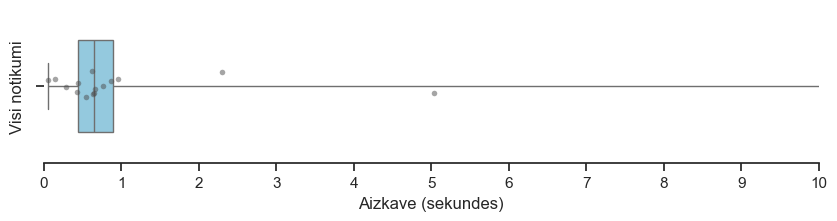

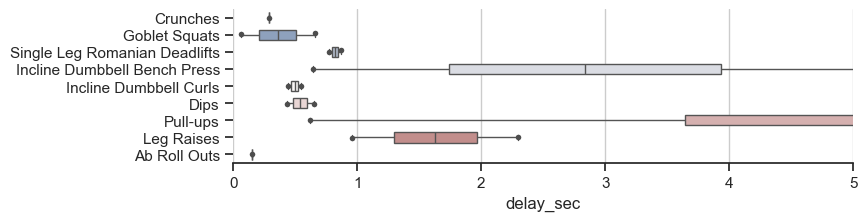

In [20]:
latency_metrics, latency_df = calculate_latency_metrics(classification, events)

print(latency_df)
print(pd.Series(latency_metrics))

plot_latency_statistics(latency_df)

# Segment level accuracy
Missed exercises intervals

In [21]:
def calculate_segment_accuracy(classification, events):
    results = []
    
    for event in events:
        name = event['name']
        start = event['start_watch']
        end = event['end_watch']
        
        # Slice the classification data to the event duration
        mask = (classification['timestamp'] >= start) & (classification['timestamp'] <= end)
        segment_df = classification.loc[mask]
        
        if segment_df.empty:
            results.append({
                'name': name,
                'accuracy': 0.0,
                'total_predictions': 0,
                'correct_predictions': 0,
                'missed_predictions': 0
            })
            continue
            
        total_preds = len(segment_df)
        # In this context, a 'correct' prediction is a 1 (Exercise) 
        # because we are inside a labeled exercise segment.
        correct_preds = int(segment_df['prediction_binary'].sum())
        missed_preds = total_preds - correct_preds
        accuracy = (correct_preds / total_preds) * 100
        
        results.append({
            'name': name,
            'accuracy': round(accuracy, 2),
            'total_predictions': total_preds,
            'correct_predictions': correct_preds,
            'missed_predictions': missed_preds
        })
        
    return pd.DataFrame(results)

# Usage
segment_acc_df = calculate_segment_accuracy(classification, events)
display(segment_acc_df)

# Overall average segment accuracy
mean_seg_acc = segment_acc_df['accuracy'].mean()
print(f"\nMean Segment Accuracy: {mean_seg_acc:.2f}%")

,name,accuracy,total_predictions,correct_predictions,missed_predictions
0,Crunches,40.91,44,18,26
1,Goblet Squats,100.00,24,24,0
2,Goblet Squats,100.00,24,24,0
3,Single Leg Romanian Deadlifts,100.00,59,59,0
4,Single Leg Romanian Deadlifts,96.43,56,54,2
5,Incline Dumbbell Bench Press,76.92,26,20,6
6,Incline Dumbbell Bench Press,83.33,24,20,4
7,Incline Dumbbell Curls,69.09,55,38,17
8,Incline Dumbbell Curls,66.67,42,28,14
9,Dips,11.76,17,2,15



Mean Segment Accuracy: 59.15%


# False triggers
During rest

In [22]:
def calculate_rest_accuracy(classification, events):
    # Sort events by time
    sorted_events = sorted(events, key=lambda x: x['start_watch'])
    rest_results = []
    
    # Get the absolute start and end of the recording
    session_start = classification['timestamp'].min()
    session_end = classification['timestamp'].max()

    # 1. Period BEFORE the first exercise
    if session_start < sorted_events[0]['start_watch']:
        rest_results.append(process_rest_segment(
            classification, session_start, sorted_events[0]['start_watch'], "Initial Rest (Pre-Workout)"
        ))

    # 2. Periods BETWEEN exercises (The Gaps)
    for i in range(len(sorted_events) - 1):
        rest_start = sorted_events[i]['end_watch']
        rest_end = sorted_events[i+1]['start_watch']
        label = f"Rest after {sorted_events[i]['name']}"
        rest_results.append(process_rest_segment(classification, rest_start, rest_end, label))

    # 3. Period AFTER the last exercise
    if session_end > sorted_events[-1]['end_watch']:
        rest_results.append(process_rest_segment(
            classification, sorted_events[-1]['end_watch'], session_end, "Final Rest (Post-Workout)"
        ))
        
    # Filter out None results (if segments were empty) and return DataFrame
    return pd.DataFrame([r for r in rest_results if r is not None])

def process_rest_segment(df, start, end, label):
    mask = (df['timestamp'] >= start) & (df['timestamp'] <= end)
    rest_df = df.loc[mask]
    
    if rest_df.empty:
        return None
        
    total_preds = len(rest_df)
    correct_preds = (rest_df['prediction_binary'] == 0).sum()
    false_positives = total_preds - correct_preds
    accuracy = (correct_preds / total_preds) * 100
    
    return {
        'period': label,
        'accuracy': round(accuracy, 2),
        'total_predictions': total_preds,
        'correct_rest_preds': int(correct_preds),
        'false_positives': int(false_positives)
    }

# Usage
rest_acc_df = calculate_rest_accuracy(classification, events)
display(rest_acc_df)

total_rest_preds = rest_acc_df['total_predictions'].sum()
total_correct_rest = rest_acc_df['correct_rest_preds'].sum()
global_rest_acc = (total_correct_rest / total_rest_preds) * 100

print(f"Global Rest Accuracy: {global_rest_acc:.2f}%")

,period,accuracy,total_predictions,correct_rest_preds,false_positives
0,Initial Rest (Pre-Workout),73.77,244,180,64
1,Rest after Crunches,83.19,226,188,38
2,Rest after Goblet Squats,92.10,367,338,29
3,Rest after Goblet Squats,92.97,427,397,30
4,Rest after Single Leg Romanian Deadlifts,90.70,301,273,28
5,Rest after Single Leg Romanian Deadlifts,93.15,292,272,20
6,Rest after Incline Dumbbell Bench Press,83.67,251,210,41
7,Rest after Incline Dumbbell Bench Press,89.45,256,229,27
8,Rest after Incline Dumbbell Curls,89.59,221,198,23
9,Rest after Incline Dumbbell Curls,94.64,336,318,18


Global Rest Accuracy: 92.31%


# Report

# Smoothing

In [23]:
def apply_smoothing_non_recursive(classification, window_size=3):
    df = classification.copy()
    
    df['prediction_binary_median'] = df['prediction_binary'].rolling(window=window_size).median().fillna(0).astype(int)
    
    return df

In [24]:
import numpy as np


def apply_state_machine(df, start_buffer=3, end_buffer=5):
    raw_binary = df['prediction_binary'].values
    smoothed = np.zeros_like(raw_binary)
    current_state = 0
    counter = 0

    for i in range(len(raw_binary)):
        if current_state == 0:
            if raw_binary[i] == 1:
                counter += 1
            else:
                counter = 0
            if counter >= start_buffer:
                current_state = 1
                counter = 0
        else:
            if raw_binary[i] == 0:
                counter += 1
            else:
                counter = 0
            if counter >= end_buffer:
                current_state = 0
                counter = 0
        
        smoothed[i] = current_state
    return smoothed

In [ ]:
def apply_inertia_strategy(clf, entry_threshold=2, max_inertia=15):
    preds = clf['prediction_binary'].values
    smoothed = np.zeros_like(preds)
    
    inertia = 0
    is_active = False
    
    for i in range(len(preds)):
        if preds[i] == 1:
            inertia = min(inertia + 1, max_inertia)
        else:
            inertia = max(inertia - 1, 0)
            
        # Entry Logic
        if not is_active and inertia >= entry_threshold:
            is_active = True
        
        # Exit Logic: Must hit 0 to exit
        if is_active and inertia == 0:
            is_active = False
            
        smoothed[i] = 1 if is_active else 0
        
    return smoothed

In [26]:
print("Non-smoothed metrics:")
print(classification_report(classification["ground_truth"], classification["prediction_binary"]))

classification_smoother_non_rec = apply_smoothing_non_recursive(classification, window_size=3)
classification_smoother_non_rec['prediction_binary'] = classification_smoother_non_rec['prediction_binary_median']
print("Smoothed metrics:")
print(classification_report(classification_smoother_non_rec["ground_truth"], classification_smoother_non_rec["prediction_binary"]))

latency_metrics, latency_df = calculate_latency_metrics(classification_smoother_non_rec, events)
print(latency_df)
print(f"Mean Detection Latency: {(latency_metrics["mean_latency"] / 1000):.2f}ms")
print(f"Median Detection Latency: {(latency_metrics["median_latency"] / 1000):.2f}ms")

print("Non-smoothed metrics:")

latency_metrics, latency_df = calculate_latency_metrics(classification, events)
print(latency_df)
print(f"Mean Detection Latency: {(latency_metrics["mean_latency"] / 1000):.2f}ms")
print(f"Median Detection Latency: {(latency_metrics["median_latency"] / 1000):.2f}ms")

Non-smoothed metrics:
              precision    recall  f1-score   support

           0       0.97      0.92      0.95      6631
           1       0.41      0.65      0.50       558

    accuracy                           0.90      7189
   macro avg       0.69      0.78      0.72      7189
weighted avg       0.93      0.90      0.91      7189

Smoothed metrics:
              precision    recall  f1-score   support

           0       0.97      0.94      0.96      6631
           1       0.48      0.66      0.56       558

    accuracy                           0.92      7189
   macro avg       0.73      0.80      0.76      7189
weighted avg       0.93      0.92      0.92      7189

                             name  delay_ms  delay_sec    status
0                        Crunches    1290.0       1.29  Detected
1                   Goblet Squats    1665.0       1.66  Detected
2                   Goblet Squats    1064.0       1.06  Detected
3   Single Leg Romanian Deadlifts     868.0   

In [27]:
# # 1. Apply state_machine
# classification_smoothed_hysteris = apply_state_machine(classification, start_buffer=2, end_buffer=3)

# print("="*60)
# print("state_machine SMOOTHED METRICS (Start=2, End=3)")
# print("="*60)

# # 2. Total Accuracy (Global Exercise vs Rest)
# total_stats = calculate_total_metrics(classification_smoothed_hysteris, filtered_events)
# print(f"Overall Accuracy:  {total_stats['overall_accuracy']}%")
# print(f"Exercise Accuracy: {total_stats['exercise_accuracy']}% (Recall)")
# print(f"Rest Accuracy:     {total_stats['rest_accuracy']}% (Specificity)")

# # 3. Latency Metrics
# latency_df = calculate_latency(classification_smoothed_hysteris, filtered_events, buffer_ms=2000)
# detections = latency_df[latency_df['status'] == 'Detected']['delay_sec']

# bias = detections.mean()
# mae = detections.abs().mean()

# print(f"\nSystem Bias:         {bias:.2f}s")
# print(f"Avg Error Magnitude: {mae:.2f}s")

# # 4. Detailed Segment Breakdown
# print("\n--- PER-SEGMENT ACCURACY ---")
# segment_acc_df = calculate_segment_accuracy(classification_smoothed_hysteris, filtered_events)
# # We merge latency and accuracy for a full view
# detailed_report = pd.merge(
#     latency_df[['name', 'status', 'delay_sec']], 
#     segment_acc_df[['name', 'accuracy', 'total_predictions', 'missed_predictions']], 
#     on='name'
# )
# display(detailed_report)

# # 5. Rest Analysis (Ghosting check)
# print("\n--- REST PERIOD ACCURACY ---")
# rest_acc_df = calculate_rest_accuracy(classification_smoothed_hysteris, filtered_events)
# display(rest_acc_df)

In [28]:
report = classification_report(classification["ground_truth"], classification["prediction_binary"], output_dict=True)
display(report)
report['0']['precision']

{'0': {'precision': 0.9686659281531887,
  'recall': 0.9230885236012668,
  'f1-score': 0.9453281853281853,
  'support': 6631.0},
 '1': {'precision': 0.41379310344827586,
  'recall': 0.6451612903225806,
  'f1-score': 0.5042016806722689,
  'support': 558.0},
 'accuracy': 0.9015162053136737,
 'macro avg': {'precision': 0.6912295158007323,
  'recall': 0.7841249069619237,
  'f1-score': 0.724764933000227,
  'support': 7189.0},
 'weighted avg': {'precision': 0.9255974852285342,
  'recall': 0.9015162053136737,
  'f1-score': 0.9110885706949956,
  'support': 7189.0}}

0.9686659281531887

In [29]:
# def color_accuracy(val):
#     if val == "" or pd.isna(val):
#         return ""
#     try:
#         pct = float(val) / 100
#     except (ValueError, TypeError):
#         return ""
#     pct_curved = pct ** 3
#     r = int(120 * (1 - pct_curved))
#     g = int(200 * pct_curved)
#     return f"background-color: rgb({r},{g},0); color: {'black' if pct_curved > 0.3 else 'white'}"


# def style_summary(df):
#     # Dynamically find columns that look like percentage/score metrics
#     # This now includes precision, recall, f1, and accuracy for all classes
#     acc_cols = [c for c in df.columns if any(m in c.lower() for m in ['precision', 'recall', 'f1-score', 'accuracy'])]
    
#     return (
#         df.fillna("")
#         .style
#         .map(color_accuracy, subset=acc_cols)
#         .format({c: lambda v: f"{v*100:.1f}" if isinstance(v, (int, float)) else "" for c in acc_cols})
#         .set_properties(subset=["Strategy"], **{"font-weight": "bold"})
#     )


# def style_per_exercise(df):
#     acc_cols   = [c for c in df.columns if c.startswith("acc_")]
#     return (
#         df.fillna("")
#         .style
#         .map(color_accuracy, subset=acc_cols)
#         .format({c: lambda v: f"{v:.1f}" if v != "" else "" for c in acc_cols})
#         .set_properties(subset=["name"], **{"font-weight": "bold"})
#     )


# def run_full_benchmarks(classification, events, buffer_ms=2000):
#     raw_df = classification.copy()

#     median_df = apply_smoothing_non_recursive(classification, window_size=3).copy()
#     median_df['prediction_binary'] = median_df['prediction_binary_median']

#     hyst_df_2_3 = classification.copy()
#     hyst_df_2_3['prediction_binary'] = apply_state_machine(classification, start_buffer=2, end_buffer=3)
#     hyst_df_1_3 = classification.copy()
#     hyst_df_1_3['prediction_binary'] = apply_state_machine(classification, start_buffer=1, end_buffer=3)

#     strategies = [
#         ("raw",        raw_df),
#         ("median_3",   median_df),
#         ("sm s=2 e=3", hyst_df_2_3),
#         ("sm s=1 e=3", hyst_df_1_3),
#     ]

#     results_list  = []
#     summary_stats = []

#     for suffix, df_variant in strategies:
#         lat_df = calculate_latency(df_variant, events, buffer_ms=buffer_ms)
#         seg_df = calculate_segment_accuracy(df_variant, events)

#         lat_df['start_key'] = [e['start_watch'] for e in events]
#         seg_df['start_key'] = [e['start_watch'] for e in events]

#         combined = pd.merge(
#             lat_df[['name', 'delay_sec', 'start_key']],
#             seg_df[['accuracy', 'start_key']],
#             on='start_key'
#         ).rename(columns={
#             'delay_sec': f'delay_{suffix}',
#             'accuracy':  f'acc_{suffix}',
#         })
#         results_list.append(combined)

#         df_variant = add_ground_truth(df_variant, events)

#         report = classification_report(df_variant["ground_truth"], df_variant["prediction_binary"], output_dict=True)

#         summary_stats.append({
#             'Strategy':            suffix.upper(),
#             ''
#             'System_delay':        lat_df[lat_df['status'] == 'Detected']['delay_sec'].mean(),
#             'System_avg_distance': lat_df[lat_df['status'] == 'Detected']['delay_sec'].abs().mean(),
#         })

#     final_table = results_list[0]
#     for next_df in results_list[1:]:
#         final_table = pd.merge(final_table, next_df.drop(columns=['name']), on='start_key')

#     print("=" * 90)
#     print(f"{'STRATEGY COMPARISON SUMMARY':^90}")
#     print("=" * 90)
#     display(style_summary(pd.DataFrame(summary_stats)))

#     print("\n" + "=" * 90)
#     print(f"{'PER-EXERCISE':^90}")
#     print("=" * 90)

#     cols = ['name'] + [c for c in final_table.columns if 'acc' in c]
#     display(style_per_exercise(final_table[cols].drop(columns=['start_key'], errors='ignore')))


# run_full_benchmarks(classification, events_watch_time, buffer_ms=2000)

In [30]:
# ── Strategy registry ──────────────────────────────────────────────────────────

from sklearn.metrics import confusion_matrix


def _strategy_raw(clf):
    return clf

def _strategy_median_3(clf):
    df = apply_smoothing_non_recursive(clf, window_size=3).copy()
    df["prediction_binary"] = df["prediction_binary_median"]
    return df

def _strategy_sm(start_buffer: int, end_buffer: int):
    def _apply(clf):
        df = clf.copy()
        df["prediction_binary"] = apply_state_machine(
            clf, start_buffer=start_buffer, end_buffer=end_buffer
        )
        return df
    return _apply

def _strategy_inertia(entry_threshold, max_inertia):
    def _apply(clf):
        df = clf.copy()

        df["prediction_binary"] = apply_inertia_strategy(clf, entry_threshold=entry_threshold, max_inertia=max_inertia)

        return df
    
    return _apply


STRATEGIES: dict[str, callable] = {
    "raw":      _strategy_raw,
    "median_3": _strategy_median_3,
    "sm_2_3":   _strategy_sm(start_buffer=2, end_buffer=3),
    "sm_1_3":   _strategy_sm(start_buffer=1, end_buffer=3),
    "inertia":  _strategy_inertia(entry_threshold=2, max_inertia=15),
    "inertia_10":  _strategy_inertia(entry_threshold=2, max_inertia=10),
    "inertia_5":  _strategy_inertia(entry_threshold=2, max_inertia=5)
}

def apply_strategy(classification, strategy: str):
    """Apply a smoothing strategy to a classification DataFrame."""
    if strategy not in STRATEGIES:
        raise ValueError(
            f"Unknown strategy '{strategy}'. Choose from: {', '.join(STRATEGIES)}"
        )
    return STRATEGIES[strategy](classification)

# ── Metric helpers ─────────────────────────────────────────────────────────────

def _extract_session_metrics(clf, filtered_events: list[dict]):
    report = classification_report(
        clf["ground_truth"],
        clf["prediction_binary"],
        output_dict=True,
        zero_division=0
    )

    latency_metrics, latency_df = calculate_latency_metrics(clf, filtered_events)

    metrics = {
        "Macro_Precision": report["macro avg"]["precision"],
        "Weighted_Precision": report["weighted avg"]["precision"],
        "Precision_0": report["0"]["precision"],
        "Precision_1": report["1"]["precision"],

        "Macro_Recall": report["macro avg"]["recall"],
        "Weighted_Recall": report["weighted avg"]["recall"],
        "Recall_0": report["0"]["recall"],
        "Recall_1": report["1"]["recall"],

        "Macro_F1": report["macro avg"]["f1-score"],
        "Weighted_F1": report["weighted avg"]["f1-score"],
        "F1_0": report["0"]["f1-score"],
        "F1_1": report["1"]["f1-score"],

        "Accuracy": report["accuracy"],

        "Mean_latency": latency_metrics["mean_latency"],
        "Median_latency": latency_metrics["median_latency"],
        "Min_latency": latency_metrics["min_latency"],
        "Max_latency": latency_metrics["max_latency"],
        "Std_latency": latency_metrics["std_latency"],
        "Q1_latency": latency_metrics["Q1_latency"],
        "Q3_latency": latency_metrics["Q3_latency"],
        "P95_latency": latency_metrics["P95"],


        "Detected_events": latency_metrics["detected_events"],
        "Total_events": latency_metrics["total_events"],
        "Detection_rate": latency_metrics["detection_rate"],
    }

    return metrics, latency_df


def _extract_global_metrics(global_clf: pd.DataFrame, all_latencies) -> dict:
    """
    Final pooled metrics across all sessions.
    This should be your main result.
    """

    report = classification_report(
        global_clf["ground_truth"],
        global_clf["prediction_binary"],
        output_dict=True,
        zero_division=0
    )

    metrics = {
        "Macro_Precision": report["macro avg"]["precision"],
        "Weighted_Precision": report["weighted avg"]["precision"],
        "Precision_0": report["0"]["precision"],
        "Precision_1": report["1"]["precision"],

        "Macro_Recall": report["macro avg"]["recall"],
        "Weighted_Recall": report["weighted avg"]["recall"],
        "Recall_0": report["0"]["recall"],
        "Recall_1": report["1"]["recall"],

        "Macro_F1": report["macro avg"]["f1-score"],
        "Weighted_F1": report["weighted avg"]["f1-score"],
        "F1_0": report["0"]["f1-score"],
        "F1_1": report["1"]["f1-score"],

        "Accuracy": report["accuracy"],

        "Mean_latency": all_latencies.mean(),
        "Median_latency": all_latencies.median(),
        "Std_latency": all_latencies.std(),
        "Min_latency": all_latencies.min(),
        "Max_latency": all_latencies.max(),
        "Q1_latency": all_latencies.quantile(0.25),
        "Q3_latency": all_latencies.quantile(0.75),
        "P95_latency": all_latencies.quantile(0.95),
    }

    return metrics

def _print_results(
    session_df: pd.DataFrame,
    global_metrics: dict,
    global_clf: pd.DataFrame,
    global_latency_df,
    all_latencies: list,
    strategy: str
) -> None:

    print("=" * 80)
    print(f"{'GLOBAL RESULTS':^80}")
    print(f"{'Strategy: ' + strategy.upper():^80}")
    print("=" * 80)

    print(classification_report(
            global_clf["ground_truth"],
            global_clf["prediction_binary"]
        ).replace(".", ","))

    print("\n── Global latency ──")
    for key, value in global_metrics.items():
        if "latency" in key.lower():
            print(f"\t{key}: {lv_float(value)}s")

    plot_latency_statistics(global_latency_df)
    plot_latency_statistics_per_session(global_latency_df)

    print("\n── Global Confusion Matrix ──")
    cm = confusion_matrix(
        global_clf["ground_truth"],
        global_clf["prediction_binary"]
    )
    print(cm)

    print("\n" + "=" * 80)
    print(f"{'PER-SESSION VARIABILITY':^80}")
    print("=" * 80)

    display(
        session_df.style.format(decimal=",", precision=2
        )
    )

    print("\n── Session Variability Summary ──")

    variability_cols = [
        "Precision_1",
        "Recall_1",
        "F1_1",
        "Mean_latency",
        "Median_latency",
        "Detection_rate",
    ]

    for col in variability_cols:
        if col not in session_df.columns:
            continue

        unit = "s" if "latency" in col.lower() else ""

        print(
            f"  {col:<18} "
            f"mean={session_df[col].mean():.2f}{unit}, "
            f"std={session_df[col].std():.2f}{unit}, "
            f"min={session_df[col].min():.2f}{unit}, "
            f"max={session_df[col].max():.2f}{unit}"
        )


# ── Main comparison ────────────────────────────────────────────────────────────

def compare_sessions(
    sessions: list[dict],
    ignore_list: list[str] | None = None,
    strategy: str = "raw",
):
    """
    Computes:
    1. Global pooled frame-level classification metrics
    2. Global pooled event-level latency metrics
    3. Per-session variability analysis

    Returns
    -------
    session_df : pd.DataFrame
        One row per session.

    global_metrics : dict
        Pooled global metrics across all sessions.

    global_clf : pd.DataFrame
        Concatenated prediction dataframe across all sessions.

    all_latencies : list
        Event-level latencies pooled across all sessions.
    """

    ignore_list = ignore_list or []

    session_rows = []
    all_clfs = []
    all_latencies = []
    all_latency_dfs = []

    for session in sessions:
        events_watch_time = convert_events_to_watch_time(
            session["annotation"],
            session["info"]
        )

        clf, events = remove_ignored_exercises(
            session["classification"],
            events_watch_time,
            ignore_list
        )

        clf = apply_strategy(clf, strategy)
        clf = add_ground_truth(clf, events)

        metrics, latency_df = _extract_session_metrics(clf, events)

        latency_df = latency_df.copy()
        latency_df["Session"] = session["name"]

        all_latency_dfs.append(latency_df)

        session_rows.append({
            "Session": session["name"],
            **metrics
        })

        all_clfs.append(clf)

    session_df = pd.DataFrame(session_rows)

    global_clf = pd.concat(all_clfs, ignore_index=True)

    global_latency_df = pd.concat(all_latency_dfs, ignore_index=True)

    all_latencies = global_latency_df.loc[
        global_latency_df["status"] == "Detected",
        "delay_sec"
    ].dropna().astype(float)

    global_metrics = _extract_global_metrics(
        global_clf,
        all_latencies
    )

    _print_results(
        session_df,
        global_metrics,
        global_clf,
        global_latency_df,
        all_latencies,
        strategy
    )

    return session_df, global_metrics, global_clf, all_latencies

In [31]:
ignore_list = ['Treadmill Running', 'Side Crunches',
               #'Chest Fly Machine', 'Dumbbell Overhead Press', 'Cable Rows'
               ]

session_paths = [
    "session_1776786984700",
    "session_1776875240569",
    "session_1776938763711",
    "session_1777025558126",
    "session_1777104300830",
    "session_1777394359098",
    "session_1777462103399"
]

sessions = []
for path in session_paths:
    accel, gyro, clf, ann, info = load_recording(path)
    sessions.append({
        "name":           path,
        "classification": clf,
        "annotation":     ann,
        "info":           info,
    })

# Compare sessions

                                 GLOBAL RESULTS                                 
                                 Strategy: RAW                                  
              precision    recall  f1-score   support

           0       0,93      0,92      0,93     29215
           1       0,56      0,61      0,58      4887

    accuracy                           0,87     34102
   macro avg       0,74      0,76      0,75     34102
weighted avg       0,88      0,87      0,88     34102


── Global latency ──
	Mean_latency: 3,31s
	Median_latency: 1,18s
	Std_latency: 6,41s
	Min_latency: 0,01s
	Max_latency: 42,10s
	Q1_latency: 0,66s
	Q3_latency: 2,98s
	P95_latency: 15,56s

── Global Confusion Matrix ──
[[26826  2389]
 [ 1907  2980]]

                            PER-SESSION VARIABILITY                             


C:\Users\piebm\AppData\Local\Temp\ipykernel_28560\1093852392.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(1, num_categories+1))


,Session,Macro_Precision,Weighted_Precision,Precision_0,Precision_1,Macro_Recall,Weighted_Recall,Recall_0,Recall_1,Macro_F1,Weighted_F1,F1_0,F1_1,Accuracy,Mean_latency,Median_latency,Min_latency,Max_latency,Std_latency,Q1_latency,Q3_latency,P95_latency,Detected_events,Total_events,Detection_rate
0,session_1776786984700,"0,79","0,90","0,95","0,64","0,84","0,89","0,92","0,76","0,81","0,90","0,93","0,69","0,89","1,11","1,13","0,05","2,62","0,67","0,68","1,45","2,23",19,22,"0,86"
1,session_1776875240569,"0,73","0,92","0,97","0,48","0,85","0,88","0,89","0,81","0,77","0,89","0,93","0,60","0,88","2,05","1,84","0,10","6,01","1,56","0,93","2,72","4,45",16,16,"1,00"
2,session_1776938763711,"0,78","0,84","0,89","0,68","0,74","0,85","0,93","0,55","0,76","0,85","0,91","0,61","0,85","9,03","1,40","0,01","42,10","15,36","1,04","3,17","38,61",14,16,"0,88"
3,session_1777025558126,"0,69","0,81","0,88","0,49","0,67","0,82","0,90","0,43","0,67","0,82","0,89","0,46","0,82","5,81","2,13","0,40","21,08","7,43","0,77","8,83","19,27",15,16,"0,94"
4,session_1777104300830,"0,81","0,85","0,88","0,75","0,70","0,86","0,96","0,44","0,74","0,85","0,92","0,56","0,86","3,57","2,78","0,26","17,45","3,86","1,08","4,35","7,91",19,20,"0,95"
5,session_1777394359098,"0,77","0,88","0,93","0,61","0,77","0,88","0,93","0,62","0,77","0,88","0,93","0,61","0,88","2,14","0,98","0,14","12,56","2,62","0,61","3,02","5,61",30,32,"0,94"
6,session_1777462103399,"0,69","0,93","0,97","0,41","0,78","0,90","0,92","0,65","0,72","0,91","0,95","0,50","0,90","1,70","0,65","0,06","12,73","3,18","0,44","0,89","6,96",16,18,"0,89"



── Session Variability Summary ──
  Precision_1        mean=0.58, std=0.12, min=0.41, max=0.75
  Recall_1           mean=0.61, std=0.15, min=0.43, max=0.81
  F1_1               mean=0.58, std=0.08, min=0.46, max=0.69
  Mean_latency       mean=3.63s, std=2.85s, min=1.11s, max=9.03s
  Median_latency     mean=1.56s, std=0.74s, min=0.65s, max=2.78s
  Detection_rate     mean=0.92, std=0.05, min=0.86, max=1.00


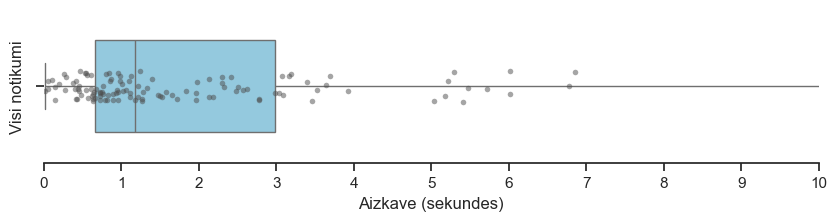

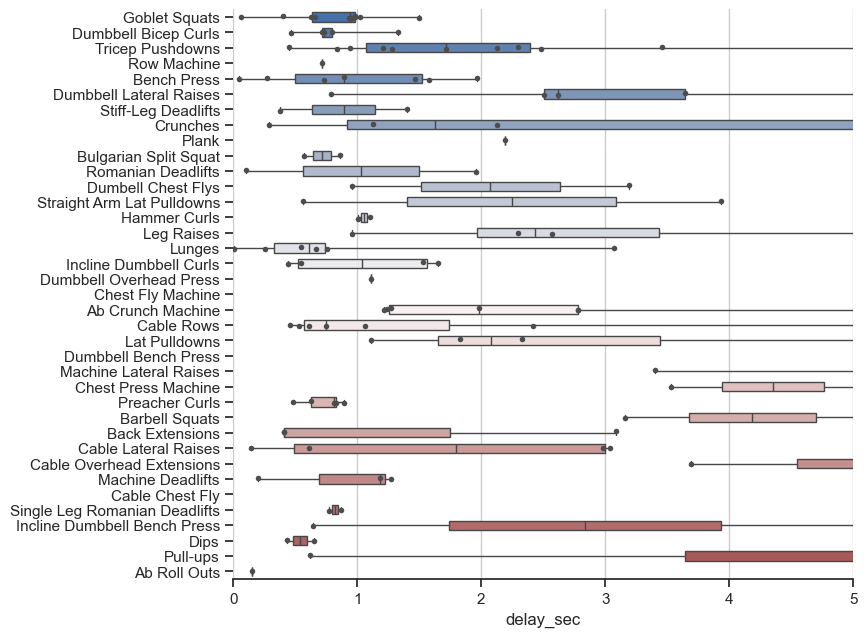

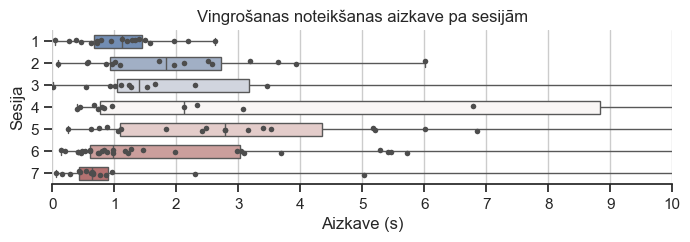

In [32]:
_ = compare_sessions(sessions, ignore_list=[])

In [33]:
# # change binary threshold
# threshold = 0.4

# for session in sessions:
#     df = session["classification"]
#     df["prediction_binary"] = (df["prediction_float"] >= threshold).astype(int)

In [34]:
# Run comparison
# compare_sessions(sessions, ignore_list=ignore_list, strategy="raw")
# compare_sessions(sessions, ignore_list=ignore_list, strategy="median_3")
# compare_sessions(sessions, ignore_list=ignore_list, strategy="sm_2_3")

In [35]:
def compare_strategies(
    sessions: list[dict],
    ignore_list: list[str] | None = None,
    strategies: list[str] | None = None,
) -> pd.DataFrame:
    """
    Compare strategies using global pooled metrics.

    Primary metrics are taken from global_metrics, not averaged from session rows.
    Session-level values are added only as variability indicators.
    """

    ignore_list = ignore_list or []

    if strategies is None:
        strategies = [
            "raw",
            "median_3",
            "sm_2_3",
            "sm_1_3",
            "inertia",
            "inertia_10",
            "inertia_5",
        ]

    rows_global = []
    rows_session = []

    for strategy in strategies:
        session_df, global_metrics, global_clf, global_latency_df = compare_sessions(
            sessions,
            ignore_list=ignore_list,
            strategy=strategy
        )

        row_global = {
            "Strategy": strategy.upper(),

            # Primary global pooled metrics
            "Global_Precision_1": round(global_metrics["Precision_1"], 2),
            "Global_Recall_1": round(global_metrics["Recall_1"], 2),
            "Global_F1_1": round(global_metrics["F1_1"], 2),

            "Global_Precision_0": round(global_metrics["Precision_0"], 2),
            "Global_Recall_0": round(global_metrics["Recall_0"], 2),
            "Global_F1_0": round(global_metrics["F1_0"], 2),

            "Global_Macro_F1": round(global_metrics["Macro_F1"], 2),
            "Global_Accuracy": round(global_metrics["Accuracy"], 2),

            # Global pooled event-level latency
            "Mean_latency": round(global_metrics["Mean_latency"], 2),
            "Median_latency": round(global_metrics["Median_latency"], 2),
            "P95_latency": round(global_metrics["P95_latency"], 2),
        }

        row_session = {
            "Strategy": strategy.upper(),
            # Session variability indicators
            "Session_F1_1_mean": round(session_df["F1_1"].mean(), 2),
            "Session_F1_1_std": round(session_df["F1_1"].std(), 2),

            "Session_Recall_1_mean": round(session_df["Recall_1"].mean(), 2),
            "Session_Recall_1_std": round(session_df["Recall_1"].std(), 2),

            "Session_latency_mean": round(session_df["Mean_latency"].mean(), 2),
            "Session_latency_std": round(session_df["Mean_latency"].std(), 2),

            "Session_detection_rate_mean": round(session_df["Detection_rate"].mean(), 2),
            "Session_detection_rate_std": round(session_df["Detection_rate"].std(), 2),
        }


        rows_global.append(row_global)
        rows_session.append(row_session)

    global_summary_df = pd.DataFrame(rows_global)
    session_summary_df = pd.DataFrame(rows_session)

    print("=" * 100)
    print(f"{'STRATEGY COMPARISON — GLOBAL POOLED METRICS':^100}")
    print("=" * 100)

    display(global_summary_df.style.format(decimal=","))

    print("=" * 100)
    print(f"{'STRATEGY COMPARISON — SESSION VARIABILITY METRICS':^100}")
    print("=" * 100)

    display(session_summary_df.style.format(decimal=","))

    return global_summary_df

In [36]:
ignore_list = ["Ab Crunch Machine","Leg Raises",
"Side Crunches",
"Ab Roll Outs",
"Preacher Curls",
"Back Extensions",
"Pull-ups",
"Chest Fly Machine",
"Chest Press Machine",
"Cable Chest Fly",
"Bulgarian Split Squat",
"Romanian Deadlifts",
"Stiff-Leg Deadlifts",
"Machine Deadlifts",
"Single Leg Romanian Deadlifts",]

                                 GLOBAL RESULTS                                 
                                 Strategy: RAW                                  
              precision    recall  f1-score   support

           0       0,93      0,92      0,93     29215
           1       0,56      0,61      0,58      4887

    accuracy                           0,87     34102
   macro avg       0,74      0,76      0,75     34102
weighted avg       0,88      0,87      0,88     34102


── Global latency ──
	Mean_latency: 3,31s
	Median_latency: 1,18s
	Std_latency: 6,41s
	Min_latency: 0,01s
	Max_latency: 42,10s
	Q1_latency: 0,66s
	Q3_latency: 2,98s
	P95_latency: 15,56s

── Global Confusion Matrix ──
[[26826  2389]
 [ 1907  2980]]

                            PER-SESSION VARIABILITY                             


C:\Users\piebm\AppData\Local\Temp\ipykernel_28560\1093852392.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(1, num_categories+1))


,Session,Macro_Precision,Weighted_Precision,Precision_0,Precision_1,Macro_Recall,Weighted_Recall,Recall_0,Recall_1,Macro_F1,Weighted_F1,F1_0,F1_1,Accuracy,Mean_latency,Median_latency,Min_latency,Max_latency,Std_latency,Q1_latency,Q3_latency,P95_latency,Detected_events,Total_events,Detection_rate
0,session_1776786984700,"0,79","0,90","0,95","0,64","0,84","0,89","0,92","0,76","0,81","0,90","0,93","0,69","0,89","1,11","1,13","0,05","2,62","0,67","0,68","1,45","2,23",19,22,"0,86"
1,session_1776875240569,"0,73","0,92","0,97","0,48","0,85","0,88","0,89","0,81","0,77","0,89","0,93","0,60","0,88","2,05","1,84","0,10","6,01","1,56","0,93","2,72","4,45",16,16,"1,00"
2,session_1776938763711,"0,78","0,84","0,89","0,68","0,74","0,85","0,93","0,55","0,76","0,85","0,91","0,61","0,85","9,03","1,40","0,01","42,10","15,36","1,04","3,17","38,61",14,16,"0,88"
3,session_1777025558126,"0,69","0,81","0,88","0,49","0,67","0,82","0,90","0,43","0,67","0,82","0,89","0,46","0,82","5,81","2,13","0,40","21,08","7,43","0,77","8,83","19,27",15,16,"0,94"
4,session_1777104300830,"0,81","0,85","0,88","0,75","0,70","0,86","0,96","0,44","0,74","0,85","0,92","0,56","0,86","3,57","2,78","0,26","17,45","3,86","1,08","4,35","7,91",19,20,"0,95"
5,session_1777394359098,"0,77","0,88","0,93","0,61","0,77","0,88","0,93","0,62","0,77","0,88","0,93","0,61","0,88","2,14","0,98","0,14","12,56","2,62","0,61","3,02","5,61",30,32,"0,94"
6,session_1777462103399,"0,69","0,93","0,97","0,41","0,78","0,90","0,92","0,65","0,72","0,91","0,95","0,50","0,90","1,70","0,65","0,06","12,73","3,18","0,44","0,89","6,96",16,18,"0,89"



── Session Variability Summary ──
  Precision_1        mean=0.58, std=0.12, min=0.41, max=0.75
  Recall_1           mean=0.61, std=0.15, min=0.43, max=0.81
  F1_1               mean=0.58, std=0.08, min=0.46, max=0.69
  Mean_latency       mean=3.63s, std=2.85s, min=1.11s, max=9.03s
  Median_latency     mean=1.56s, std=0.74s, min=0.65s, max=2.78s
  Detection_rate     mean=0.92, std=0.05, min=0.86, max=1.00
                                 GLOBAL RESULTS                                 
                               Strategy: MEDIAN_3                               
              precision    recall  f1-score   support

           0       0,94      0,93      0,93     29215
           1       0,61      0,61      0,61      4887

    accuracy                           0,89     34102
   macro avg       0,77      0,77      0,77     34102
weighted avg       0,89      0,89      0,89     34102


── Global latency ──
	Mean_latency: 4,07s
	Median_latency: 2,02s
	Std_latency: 7,37s
	Min_latency: 0,

C:\Users\piebm\AppData\Local\Temp\ipykernel_28560\1093852392.py:38: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels(range(1, num_categories+1))


...

,Session,Macro_Precision,Weighted_Precision,Precision_0,Precision_1,Macro_Recall,Weighted_Recall,Recall_0,Recall_1,Macro_F1,Weighted_F1,F1_0,F1_1,Accuracy,Mean_latency,Median_latency,Min_latency,Max_latency,Std_latency,Q1_latency,Q3_latency,P95_latency,Detected_events,Total_events,Detection_rate
0,session_1776786984700,"0,78","0,90","0,96","0,61","0,85","0,89","0,90","0,80","0,81","0,89","0,93","0,69","0,89","1,92","1,89","0,38","7,32","1,65","0,74","2,47","3,81",18,22,"0,82"
1,session_1776875240569,"0,71","0,92","0,98","0,45","0,86","0,86","0,86","0,86","0,75","0,88","0,92","0,59","0,86","4,82","2,06","0,10","25,65","7,43","0,95","3,73","21,97",16,16,"1,00"
2,session_1776938763711,"0,79","0,85","0,90","0,68","0,76","0,86","0,93","0,60","0,77","0,85","0,91","0,63","0,86","1,92","2,14","0,01","4,47","1,32","0,66","2,57","3,83",12,16,"0,75"
3,session_1777025558126,"0,69","0,82","0,89","0,49","0,68","0,82","0,90","0,46","0,68","0,82","0,89","0,47","0,82","12,51","2,59","0,96","46,66","17,04","1,69","17,84","46,29",14,16,"0,88"
4,session_1777104300830,"0,83","0,87","0,89","0,78","0,73","0,88","0,97","0,50","0,77","0,86","0,93","0,61","0,88","4,44","3,79","0,76","9,11","2,74","2,30","6,72","8,59",14,20,"0,70"
5,session_1777394359098,"0,79","0,89","0,94","0,63","0,80","0,89","0,93","0,67","0,79","0,89","0,93","0,65","0,89","3,98","1,99","0,41","33,53","6,45","0,68","4,46","9,33",27,32,"0,84"
6,session_1777462103399,"0,70","0,93","0,97","0,43","0,81","0,90","0,92","0,71","0,74","0,91","0,95","0,53","0,90","1,95","1,50","0,15","6,02","1,67","1,01","1,65","5,50",16,18,"0,89"



── Session Variability Summary ──
  Precision_1        mean=0.58, std=0.13, min=0.43, max=0.78
  Recall_1           mean=0.66, std=0.15, min=0.46, max=0.86
  F1_1               mean=0.60, std=0.07, min=0.47, max=0.69
  Mean_latency       mean=4.51s, std=3.75s, min=1.92s, max=12.51s
  Median_latency     mean=2.28s, std=0.74s, min=1.50s, max=3.79s
  Detection_rate     mean=0.84, std=0.10, min=0.70, max=1.00
                            STRATEGY COMPARISON — GLOBAL POOLED METRICS                             


,Strategy,Global_Precision_1,Global_Recall_1,Global_F1_1,Global_Precision_0,Global_Recall_0,Global_F1_0,Global_Macro_F1,Global_Accuracy,Mean_latency,Median_latency,P95_latency
0,RAW,"0,560000","0,610000","0,580000","0,930000","0,920000","0,930000","0,750000","0,870000","3,310000","1,180000","15,560000"
1,MEDIAN_3,"0,610000","0,610000","0,610000","0,940000","0,930000","0,930000","0,770000","0,890000","4,070000","2,020000","10,390000"
2,SM_2_3,"0,570000","0,660000","0,610000","0,940000","0,920000","0,930000","0,770000","0,880000","4,310000","1,990000","20,260000"
3,SM_1_3,"0,450000","0,750000","0,560000","0,950000","0,840000","0,900000","0,730000","0,830000","2,450000","0,890000","8,860000"
4,INERTIA,"0,470000","0,670000","0,550000","0,940000","0,870000","0,910000","0,730000","0,840000","4,360000","2,020000","20,290000"
5,INERTIA_10,"0,500000","0,670000","0,570000","0,940000","0,890000","0,910000","0,740000","0,860000","4,360000","2,020000","20,290000"
6,INERTIA_5,"0,550000","0,660000","0,600000","0,940000","0,910000","0,930000","0,760000","0,870000","4,360000","2,020000","20,290000"


                         STRATEGY COMPARISON — SESSION VARIABILITY METRICS                          


,Strategy,Session_F1_1_mean,Session_F1_1_std,Session_Recall_1_mean,Session_Recall_1_std,Session_latency_mean,Session_latency_std,Session_detection_rate_mean,Session_detection_rate_std
0,RAW,"0,580000","0,080000","0,610000","0,150000","3,630000","2,850000","0,920000","0,050000"
1,MEDIAN_3,"0,600000","0,090000","0,610000","0,170000","4,200000","3,820000","0,840000","0,100000"
2,SM_2_3,"0,610000","0,070000","0,660000","0,150000","4,470000","3,760000","0,850000","0,090000"
3,SM_1_3,"0,560000","0,070000","0,750000","0,120000","2,580000","1,830000","0,940000","0,050000"
4,INERTIA,"0,550000","0,060000","0,670000","0,140000","4,490000","3,720000","0,840000","0,100000"
5,INERTIA_10,"0,570000","0,060000","0,670000","0,140000","4,510000","3,750000","0,840000","0,100000"
6,INERTIA_5,"0,600000","0,070000","0,660000","0,150000","4,510000","3,750000","0,840000","0,100000"


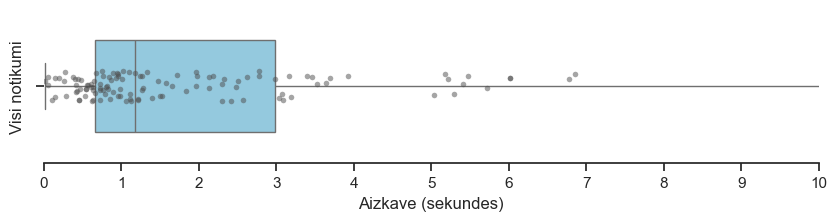

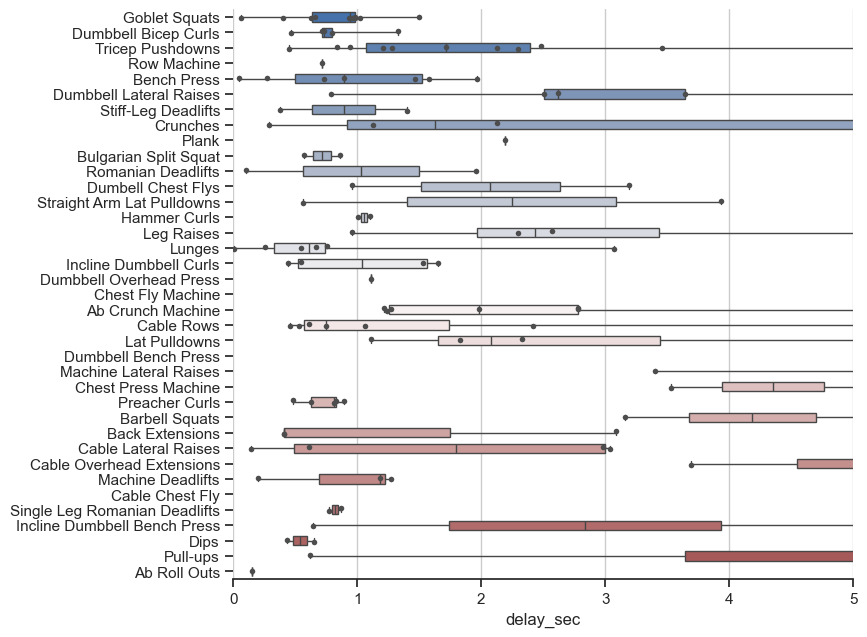

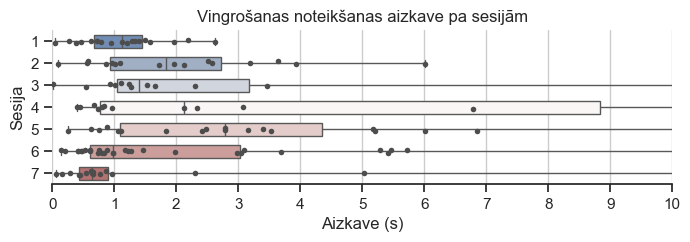

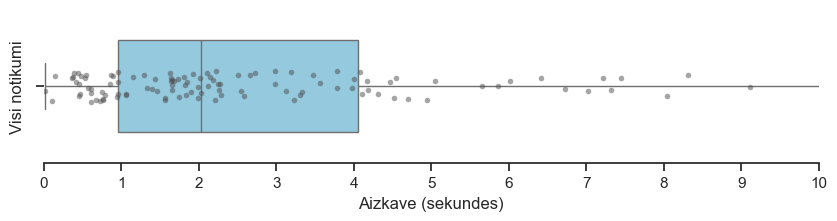

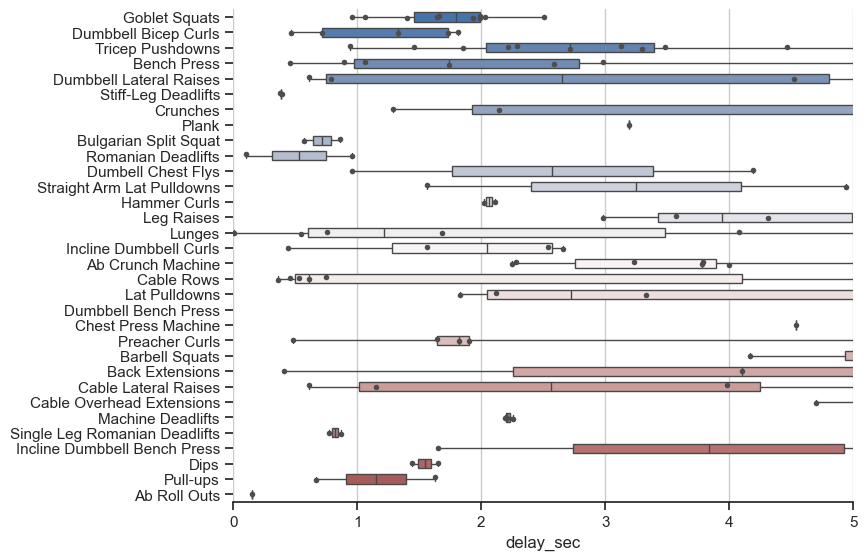

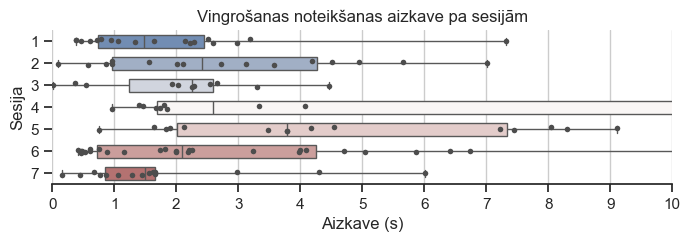

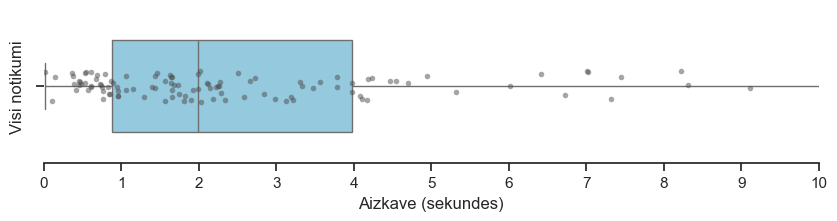

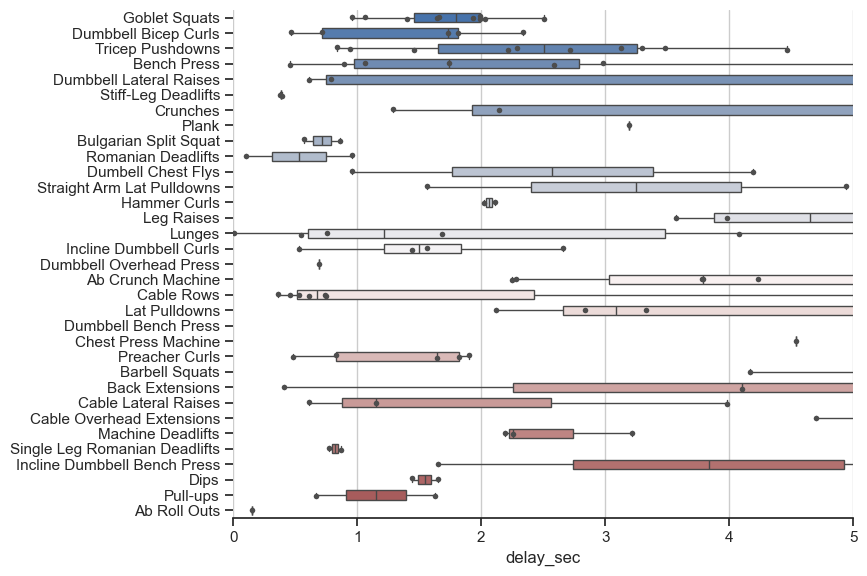

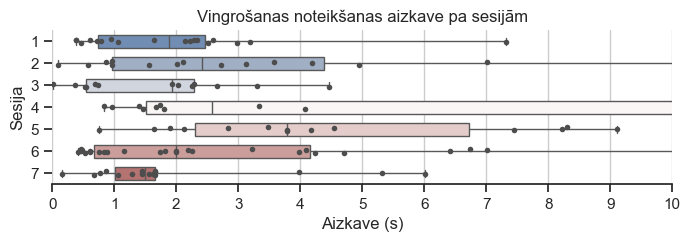

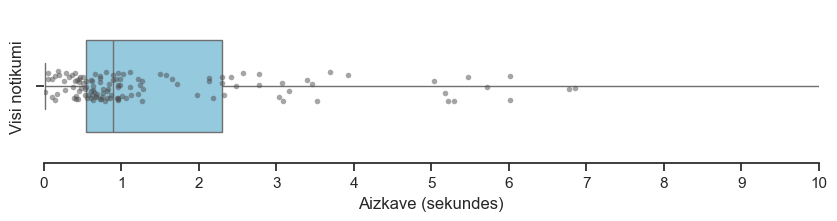

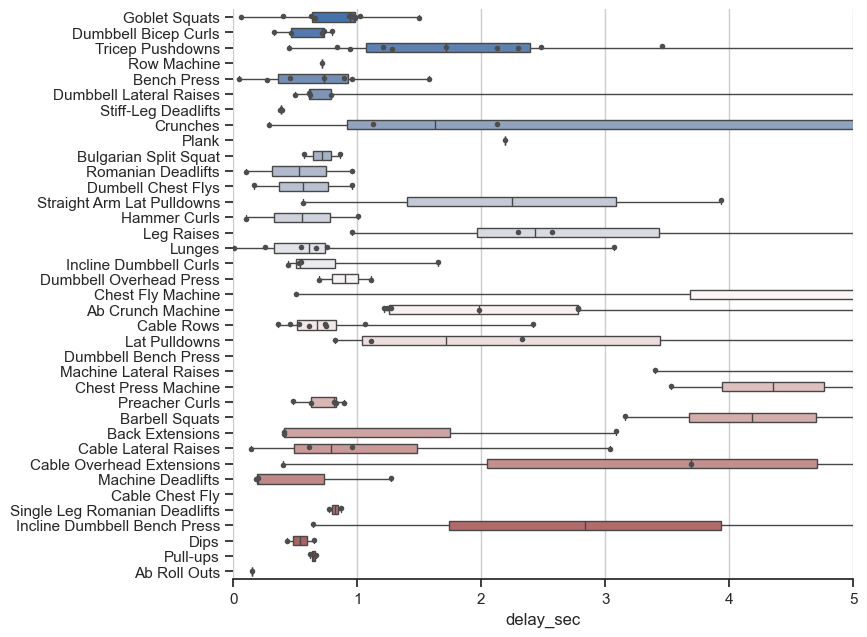

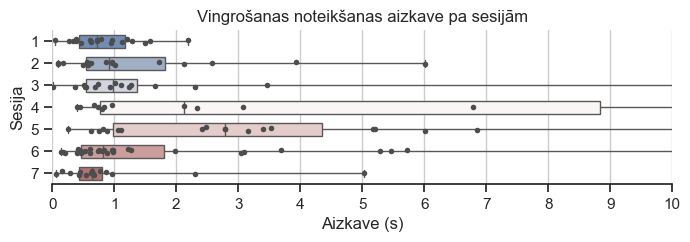

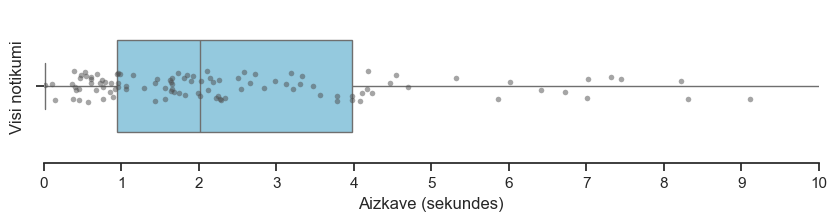

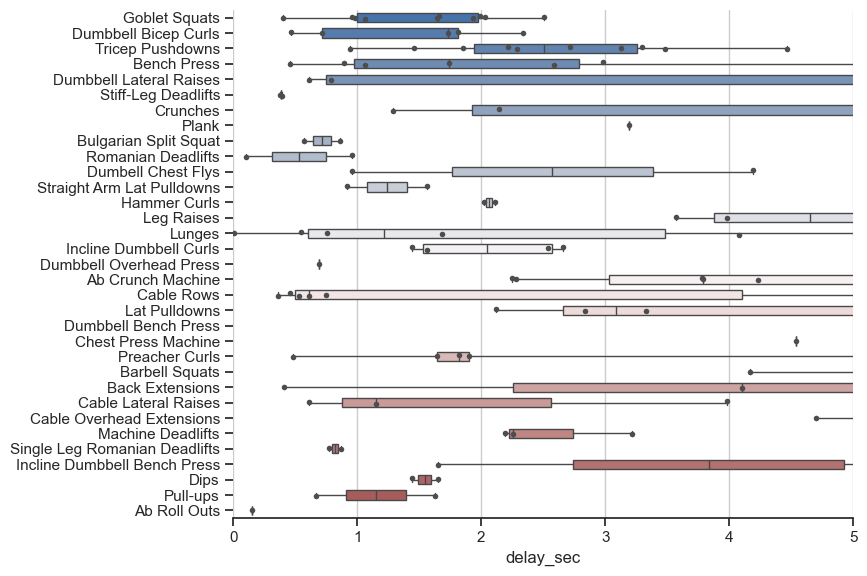

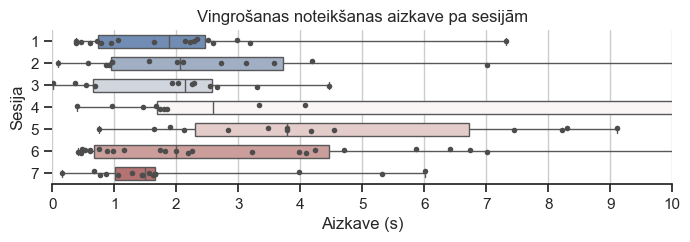

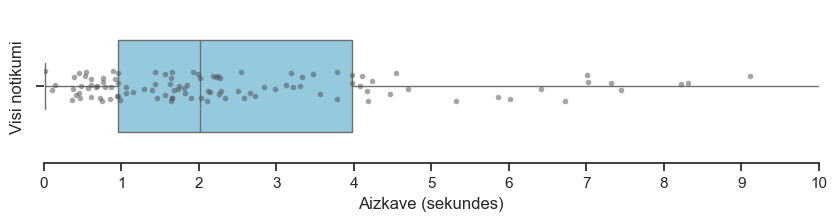

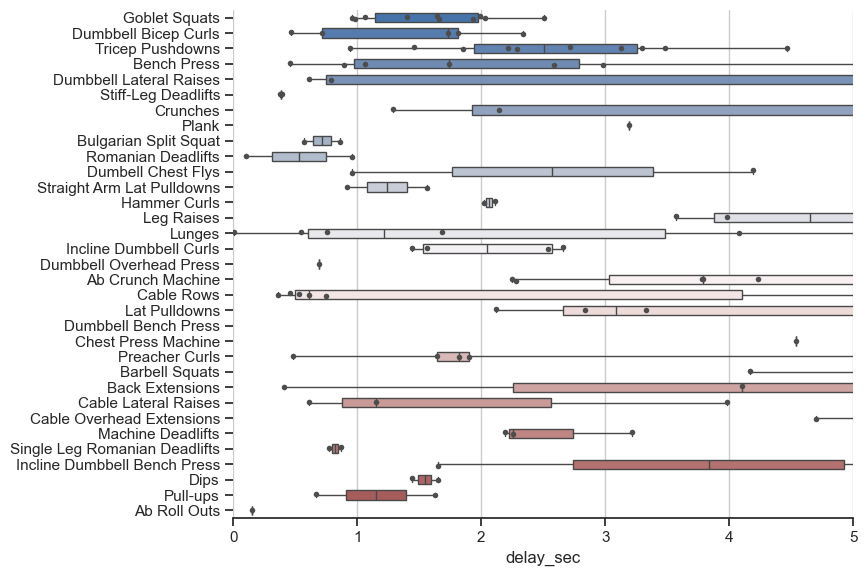

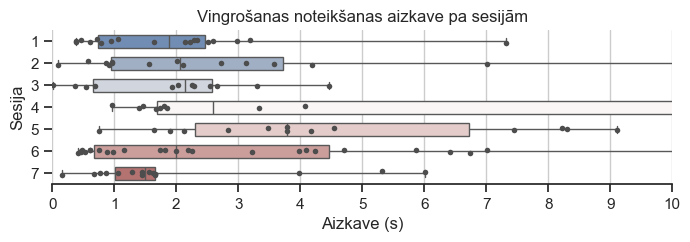

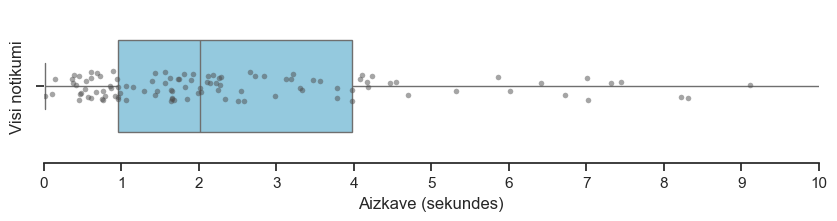

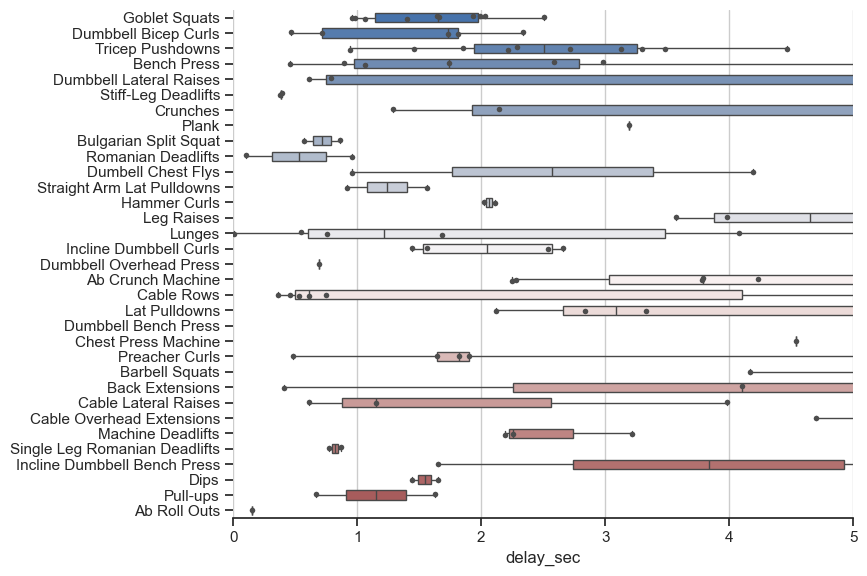

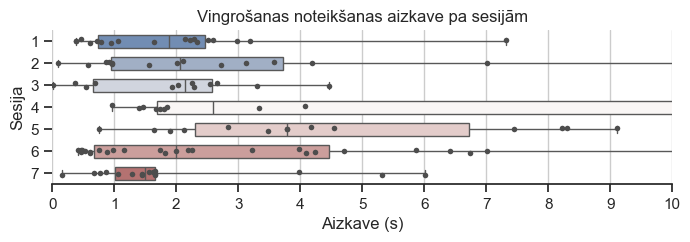

In [37]:
summary = compare_strategies(sessions, ignore_list=[])

# Compare ex

In [ ]:
EXERCISE_GROUPS = {
    "Ab Crunch Machine":        "Vēders",
    "Crunches":                 "Vēders",
    "Leg Raises":               "Vēders",
    "Plank":                    "Vēders",
    "Ab Roll Outs":             "Vēders",

    "Dumbbell Bicep Curls":     "Bicepsi",
    "Hammer Curls":             "Bicepsi",
    "Incline Dumbbell Curls":   "Bicepsi",
    "Preacher Curls":           "Bicepsi",
    "Tricep Pushdowns":         "Tricepsi",
    "Cable Overhead Extensions": "Tricepsi",
    "Dips":                     "Tricepsi",

    "Cable Rows":               "Mugura",
    "Lat Pulldowns":            "Mugura",
    "Row Machine":              "Mugura",
    "Straight Arm Lat Pulldowns": "Mugura",
    "Back Extensions":          "Mugura",
    "Pull-ups":                 "Mugura",

    "Bench Press":              "Krūtis",
    "Chest Fly Machine":        "Krūtis",
    "Chest Press Machine":      "Krūtis",
    "Dumbbell Bench Press":     "Krūtis",
    "Dumbell Chest Flys":       "Krūtis",
    "Cable Chest Fly":          "Krūtis",
    "Incline Dumbbell Bench Press": "Krūtis",

    "Barbell Squats":           "Kājas",
    "Bulgarian Split Squat":    "Kājas",
    "Goblet Squats":            "Kājas",
    "Lunges":                   "Kājas",
    "Romanian Deadlifts":       "Kājas",
    "Stiff-Leg Deadlifts":      "Kājas",
    "Machine Deadlifts":        "Kājas",
    "Single Leg Romanian Deadlifts": "Kājas",

    "Dumbbell Lateral Raises":  "Pleci",
    "Dumbbell Overhead Press":  "Pleci",
    "Machine Lateral Raises":   "Pleci",
    "Cable Lateral Raises":     "Pleci",

}

GROUP_ORDER = ["Vēders", "Bicepsi", "Tricepsi", "Mugura", "Krūtis", "Kājas", "Pleci"]

import pandas as pd


def compare_exercise_coverage_across_sessions(
    sessions,
    ignore_exercise_list=None,
    strategy=None
):
    """
    Compare exercise segment coverage across sessions.

    Coverage means:
    percentage of samples inside an annotated exercise segment
    that were predicted as exercise.

    This is equivalent to recall inside annotated exercise segments,
    not full classification accuracy.
    """

    ignore_exercise_list = ignore_exercise_list or []

    segment_rows = []

    for session in sessions:
        session_name = session["name"]
        classification = session["classification"]
        annotation = session["annotation"]
        info = session["info"]

        events = convert_events_to_watch_time(annotation, info)

        classification, events = remove_ignored_exercises(
            classification,
            events,
            ignore_exercise_list
        )

        if strategy is not None:
            classification = apply_strategy(classification, strategy)

        coverage_df = calculate_segment_accuracy(classification, events)

        coverage_df = coverage_df.rename(columns={
            "accuracy": "coverage"
        })

        coverage_df["session"] = session_name

        segment_rows.append(coverage_df)

    combined = pd.concat(segment_rows, ignore_index=True)

    combined["set"] = (
        combined
        .groupby(["name", "session"])
        .cumcount() + 1
    )

    session_mapping = create_session_mapping(combined)

    per_set = create_per_set_coverage(combined, session_mapping)
    per_session = create_per_session_coverage(combined, session_mapping)
    overall = create_overall_coverage(combined)

    pivot = create_coverage_pivot(per_set, per_session, overall)

    return pivot, session_mapping, combined


def create_session_mapping(combined):
    session_order = combined["session"].unique()

    return {
        session_name: i + 1
        for i, session_name in enumerate(session_order)
    }


def create_per_set_coverage(combined, session_mapping):
    per_set = combined[[
        "name",
        "session",
        "set",
        "coverage"
    ]].copy()

    per_set["col"] = (
        per_set["session"].map(session_mapping).astype(str)
        + "_"
        + per_set["set"].astype(str)
    )

    return per_set[["name", "col", "coverage"]]


def create_per_session_coverage(combined, session_mapping):
    per_session = (
        combined
        .groupby(["name", "session"], as_index=False)
        .agg(
            correct_predictions=("correct_predictions", "sum"),
            total_predictions=("total_predictions", "sum")
        )
    )

    per_session["coverage"] = (
        per_session["correct_predictions"]
        / per_session["total_predictions"]
        * 100
    ).round(2)

    per_session["col"] = (
        per_session["session"].map(session_mapping).astype(str)
        + "_session"
    )

    return per_session[["name", "col", "coverage"]]


def create_overall_coverage(combined):
    overall = (
        combined
        .groupby("name", as_index=False)
        .agg(
            correct_predictions=("correct_predictions", "sum"),
            total_predictions=("total_predictions", "sum")
        )
    )

    overall["coverage"] = (
        overall["correct_predictions"]
        / overall["total_predictions"]
        * 100
    ).round(2)

    overall["col"] = "overall_coverage"

    return overall[["name", "col", "coverage"]]


def create_coverage_pivot(per_set, per_session, overall):
    long_df = pd.concat(
        [overall, per_session, per_set],
        ignore_index=True
    )

    pivot = (
        long_df
        .pivot_table(
            index="name",
            columns="col",
            values="coverage",
            aggfunc="mean"
        )
        .round(2)
        .rename_axis(None, axis=1)
        .reset_index()
        .rename(columns={"name": "exercise"})
    )

    return pivot[sorted(pivot.columns, key=coverage_column_sort_key)]


def coverage_column_sort_key(col):
    if col == "exercise":
        return (0, -1, -1)

    if col == "overall_coverage":
        return (1, -1, -1)

    session_id, value_type = col.split("_", 1)

    if value_type == "session":
        return (2, int(session_id), 0)

    return (3, int(session_id), int(value_type))

def style_coverage_pivot(pivot):
    def top_label(col):
        if col in ("group", "exercise"):
            return ""

        if col == "overall_coverage":
            return "Kopā"

        if col.endswith("_session"):
            return "Sesijas pārklājums"

        return f"Sesija {col.split('_')[0]}"

    styled_pivot = pivot.copy()

    styled_pivot.columns = pd.MultiIndex.from_tuples(
        [(top_label(col), col) for col in styled_pivot.columns]
    )

    numeric_cols = [
        col for col in styled_pivot.columns
        if col[1] not in ("group", "exercise")
    ]

    border_positions = get_border_positions(styled_pivot)
    group_break_rows = get_group_break_rows(styled_pivot)

    return (
        styled_pivot
        .fillna("")
        .style
        .map(color_coverage, subset=numeric_cols)
        .set_properties(
            subset=[("", "exercise")],
            **{"font-weight": "bold"}
        )
        .set_properties(
            subset=[("", "group")],
            **{
                "font-weight": "bold",
                "color": "#666",
                "font-style": "italic"
            }
        )
        .format({
            col: lambda v: f"{v:.1f}".replace(".", ",") if v != "" else ""
            for col in numeric_cols
        })
        .set_table_styles(
            [
                {
                    "selector": "table",
                    "props": [("font-size", "11px")]
                },
                {
                    "selector": "th, td",
                    "props": [("padding", "2px 6px")]
                },
            ]
            + make_column_border_styles(border_positions)
            + make_row_border_styles(group_break_rows)
        )
    )


def get_border_positions(styled_pivot):
    bottom_cols = list(styled_pivot.columns.get_level_values(1))

    positions = []

    for i, col in enumerate(bottom_cols):
        if col == "overall_coverage":
            positions.append(i)

        elif col.endswith("_session"):
            positions.append(i)

        elif "_" in col:
            session_id = col.split("_")[0]
            previous_col = bottom_cols[i - 1] if i > 0 else ""

            if not previous_col.startswith(session_id + "_"):
                positions.append(i)

    return set(positions)


def get_group_break_rows(styled_pivot):
    if ("", "group") not in styled_pivot.columns:
        return []

    rows = []
    previous_group = None

    for i, (_, row) in enumerate(styled_pivot.iterrows()):
        current_group = row[("", "group")]

        if previous_group is not None and current_group != previous_group:
            rows.append(i)

        previous_group = current_group

    return rows


def make_column_border_styles(positions):
    return [
        {
            "selector": f"th.col{i}, td.col{i}",
            "props": [("border-left", "2px solid #555")]
        }
        for i in positions
    ]


def make_row_border_styles(rows):
    return [
        {
            "selector": f"tr:nth-child({i + 1})",
            "props": [("border-top", "2px solid #555")]
        }
        for i in rows
    ]


def color_coverage(val):
    if val == "" or pd.isna(val):
        return ""

    pct = float(val) / 100
    pct_curved = pct ** 3

    red = int(180 * (1 - pct_curved))
    green = int(255 * pct_curved)

    text_color = "black" if pct_curved > 0.3 else "white"

    return (
        f"background-color: rgb({red},{green},0); "
        f"color: {text_color}"
    )

pivot, session_mapping, combined_coverage = compare_exercise_coverage_across_sessions(
    sessions,
    ignore_exercise_list=[],
    strategy="raw"
)

pivot.insert(
    0,
    "group",
    pivot["exercise"].map(EXERCISE_GROUPS).fillna("Other")
)

pivot = (
    pivot
    .sort_values(
        ["group", "exercise"],
        key=lambda col: col.map(
            lambda value: (
                GROUP_ORDER.index(value), value
            )
            if value in GROUP_ORDER
            else (999, value)
        )
    )
    .reset_index(drop=True)
)

print("Session mapping:")
for original, number in session_mapping.items():
    print(f"  {number} → {original}")

display(style_coverage_pivot(pivot))

Session mapping:
  1 → session_1776786984700
  2 → session_1776875240569
  3 → session_1776938763711
  4 → session_1777025558126
  5 → session_1777104300830
  6 → session_1777394359098
  7 → session_1777462103399


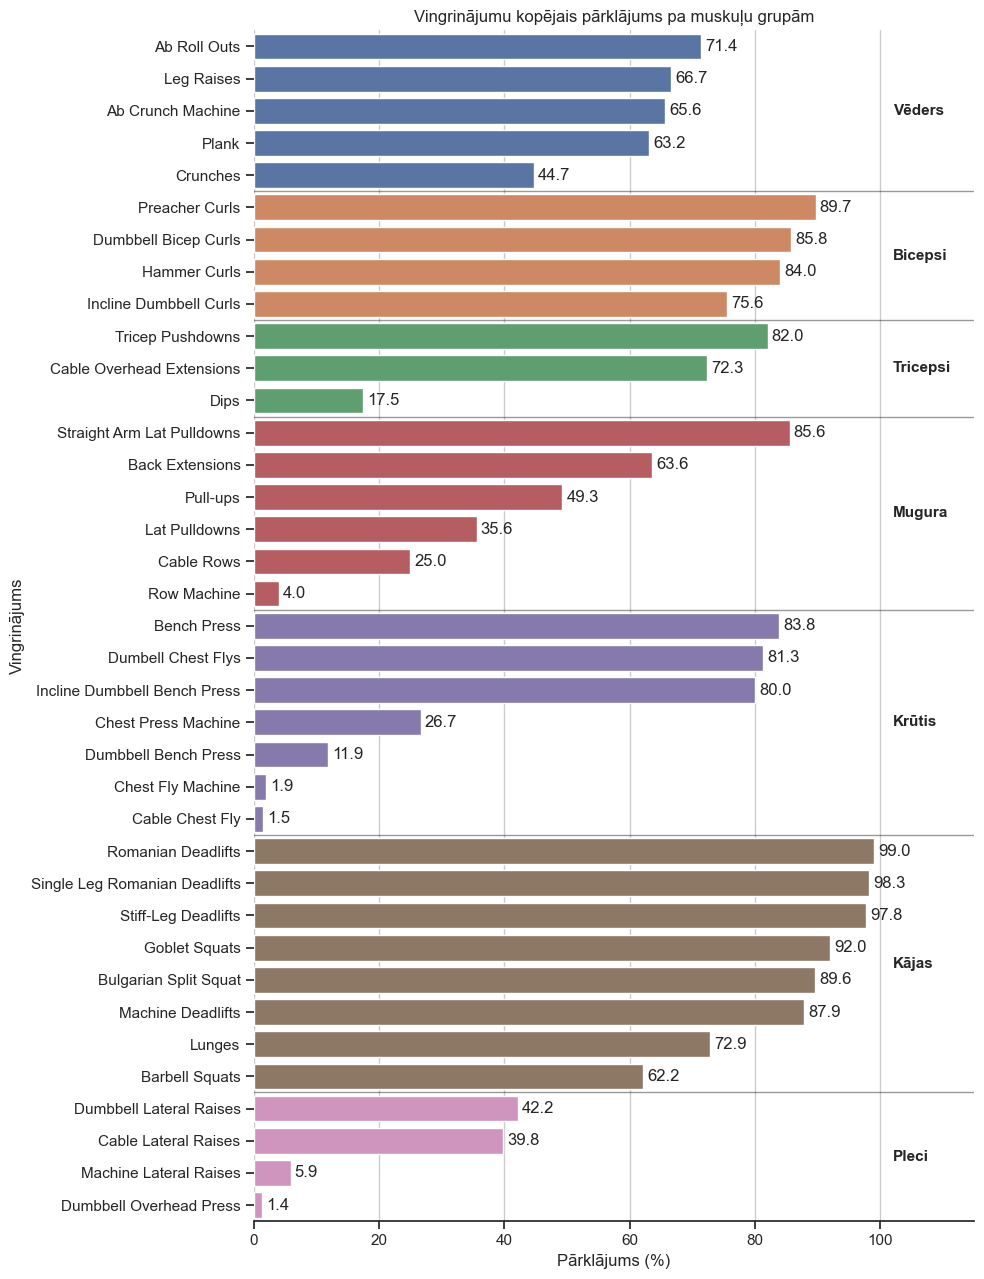

In [45]:
def plot_overall_exercise_coverage_grouped(pivot):
    plot_df = pivot[["group", "exercise", "overall_coverage"]].copy()

    plot_df["group_order"] = plot_df["group"].map(
        lambda g: GROUP_ORDER.index(g) if g in GROUP_ORDER else 999
    )

    plot_df = (
        plot_df
        .sort_values(
            ["group_order", "overall_coverage"],
            ascending=[True, False]
        )
        .reset_index(drop=True)
    )

    plt.figure(figsize=(10, max(8, len(plot_df) * 0.35)))

    ax = sns.barplot(
        data=plot_df,
        x="overall_coverage",
        y="exercise",
        hue="group",
        dodge=False
    )

    # Add values to bars
    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f",
            padding=3
        )

    # Visually separate muscle groups
    group_change_indices = (
        plot_df["group"] != plot_df["group"].shift()
    )

    group_start_indices = plot_df.index[group_change_indices].tolist()

    for idx in group_start_indices[1:]:
        ax.axhline(
            idx - 0.5,
            color="black",
            linewidth=1,
            alpha=0.4
        )

    # Add group names on the left side
    # Add group names on the right side
    for group, group_df in plot_df.groupby("group", sort=False):
        middle = (group_df.index.min() + group_df.index.max()) / 2

        ax.text(
            102,                 # x position to the right of bars
            middle,
            group,
            va="center",
            ha="left",
            fontweight="bold",
            fontsize=11
        )

    ax.set(
        xlabel="Pārklājums (%)",
        ylabel="Vingrinājums",
        title="Vingrinājumu kopējais pārklājums pa muskuļu grupām"
    )

    ax.set_xlim(0, 115)

    ax.xaxis.grid(True)

    # Hide legend because group labels are shown on the left
    legend = ax.get_legend()
    if legend is not None:
        legend.remove()

    sns.despine(left=True)
    

    plt.tight_layout()
    plt.show()

plot_overall_exercise_coverage_grouped(pivot)

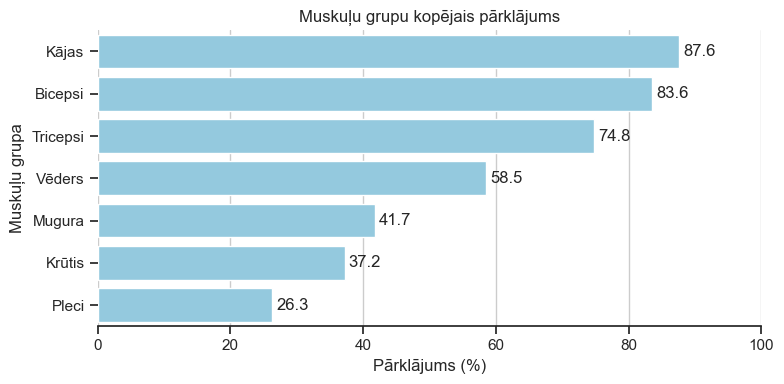

In [40]:
def plot_muscle_group_coverage(combined_coverage):
    df = combined_coverage.copy()

    df["group"] = (
        df["name"]
        .map(EXERCISE_GROUPS)
        .fillna("Other")
    )

    group_df = (
        df
        .groupby("group", as_index=False)
        .agg(
            correct_predictions=("correct_predictions", "sum"),
            total_predictions=("total_predictions", "sum")
        )
    )

    group_df["coverage"] = (
        group_df["correct_predictions"]
        / group_df["total_predictions"]
        * 100
    )

    group_df = (
        group_df
        .sort_values("coverage", ascending=False)
    )

    plt.figure(figsize=(8, 4))

    ax = sns.barplot(
        data=group_df,
        x="coverage",
        y="group",
        color="skyblue"
    )

    for container in ax.containers:
        ax.bar_label(
            container,
            fmt="%.1f",
            padding=3
        )

    ax.set(
        xlabel="Pārklājums (%)",
        ylabel="Muskuļu grupa",
        title="Muskuļu grupu kopējais pārklājums"
    )

    ax.set_xlim(0, 100)

    ax.xaxis.grid(True)

    sns.despine(left=True)

    plt.tight_layout()
    plt.show()

plot_muscle_group_coverage(combined_coverage)

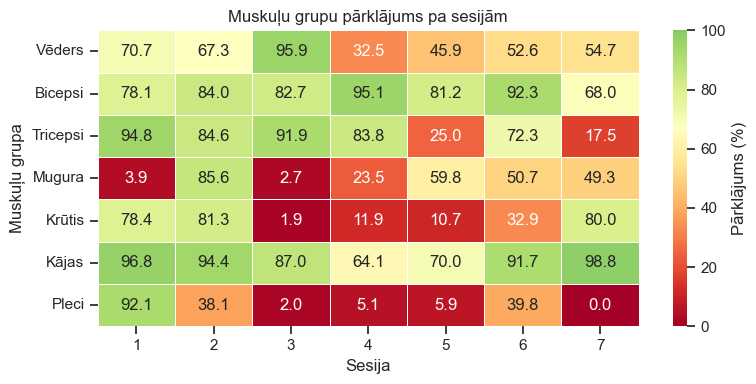

In [41]:
def plot_session_muscle_group_coverage_heatmap(combined_coverage):
    df = combined_coverage.copy()

    session_mapping = {
        session_name: i + 1
        for i, session_name in enumerate(df["session"].unique())
    }

    df["session_label"] = df["session"].map(session_mapping)

    df["group"] = (
        df["name"]
        .map(EXERCISE_GROUPS)
        .fillna("Other")
    )

    group_session_df = (
        df
        .groupby(["group", "session_label"], as_index=False)
        .agg(
            correct_predictions=("correct_predictions", "sum"),
            total_predictions=("total_predictions", "sum")
        )
    )

    group_session_df["coverage"] = (
        group_session_df["correct_predictions"]
        / group_session_df["total_predictions"]
        * 100
    )

    group_session_df["group_order"] = group_session_df["group"].map(
        lambda g: GROUP_ORDER.index(g) if g in GROUP_ORDER else 999
    )

    group_order = (
        group_session_df[["group", "group_order"]]
        .drop_duplicates()
        .sort_values(["group_order", "group"])
        ["group"]
    )

    matrix = (
        group_session_df
        .pivot(
            index="group",
            columns="session_label",
            values="coverage"
        )
        .reindex(group_order)
    )

    plt.figure(figsize=(8, 4))

    ax = sns.heatmap(
        matrix,
        annot=True,
        fmt=".1f",
        cmap="RdYlGn",
        vmin=0,
        vmax=100,
        center=67,
        linewidths=0.5,
        cbar_kws={"label": "Pārklājums (%)"}
    )

    ax.set(
        xlabel="Sesija",
        ylabel="Muskuļu grupa",
        title="Muskuļu grupu pārklājums pa sesijām"
    )

    plt.tight_layout()
    plt.show()

    return session_mapping

session_mapping = plot_session_muscle_group_coverage_heatmap(combined_coverage)